<div class="usecase-title"><h1>Urban Pedestrian Climate Impact Prediction</h1></div>

<div class="usecase-authors"><b>Authored by: </b> Maverick Nguyen, Don Thivain Adrian Vithanage</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Data Cleaning, Data Validation, Data Visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning</div>
</div>

<div class="usecase-section-header"><strong>Scenario</strong></div>

As a local living near Melbourne CBD, Maverick relies on active travel, like walking, and public transport, like trams, to get around to different places he wants to go. One morning in January, Maverick prepared to travel to his workplace, expecting to get to work before 9:00 AM, but there was a sudden heatwave, causing the tram that he usually catches to be unable to follow its designated schedule and creating a delay in his schedule. Although there was a replacement bus for this emergency, only a limited number of people could board this vehicle, which further delayed his schedule. Because of this sudden extreme weather, travel conditions become less reliable and difficult to predict.

Maverick wants to have access to a system that could predict how climate conditions over time can affect urban pedestrian movement. So that he could better plan his trip, allowing him to leave earlier in anticipation of sudden extreme weather change during a particular timeframe, or choose a different mode of transport, like an Uber. This allows more support in making informed decisions when travelling during extreme weather events.

<div class="usecase-section-header">What this use case will teach you</div>

**At the end of this use case, you will:**
- Learn how to source and combine multiple public datasets.  
- Understand how to clean and align time-series data at an hourly level for modelling. 
- Explore how climate variables, such as temperature, humidity, pressure, and wind, relate to pedestrian counts.
- Apply feature engineering techniques to create meaningful predictors from weather and mobility time-series data. 
- Build a deep learning forecasting model to predict pedestrian demand. 
- Perform model optimisation like hyperparameter tuning to improve forecasting performance. 
- Evaluate model performance and interpret results for climate adaptation planning.

<div class="usecase-section-header"><strong>Introduction</strong></div>

Urban systems are often affected by changing climate conditions, but these effects are not always easy to capture with simple forecasting methods. One clear example is pedestrian movement, where changing weather conditions can affect how many people move through the city over time.

This use case focuses on predicting pedestrian activity in the City of Melbourne using hourly climate observations, which keeps the project closely aligned with the goal of modelling how climate factors influence an urban system.

In this use case, pedestrian counts are aggregated into hourly city-level totals and merged with hourly microclimate observations for Melbourne. A deep learning model can then be trained to predict pedestrian demand based on time, recent demand history, and recent climate conditions.

The datasets used in this project are the "Pedestrian Counting System (counts per hour)", the "Pedestrian Counting System - Sensor Locations" dataset for supporting location metadata, and the "Microclimate Sensor Readings" dataset from the City of Melbourne website.

## 1. Importing The Libraries

This section is to show what libraries were used for this use case, with each imported library supporting a specific part of the pipeline. These libraries are necessary for doing data handling, time-series analysis, visualisation, feature engineering, optimisation, and deep learning <a href="#fn-1">[1]</a> <a href="#fn-2">[2]</a> <a href="#fn-3">[3]</a> <a href="#fn-4">[4]</a> <a href="#fn-5">[5]</a>. These were added at the beginning to ensure the workflow is organised <a href="#fn-6">[6]</a>. A random seed was set with a student ID to allow reproducibility of the outputs in this notebook <a href="#fn-7">[7]</a>.

The following libraries support the deep learning pipeline for this section. TensorFlow and Keras are used for building and training the recurrent neural network models <a href="#fn-3">[3]</a>. The os and random libraries are imported to support full reproducibility across all system-level random operations <a href="#fn-55">[55]</a>.

In [51]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
import os
import random

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## 2. Importing The Datasets

This section is necessary for importing multiple public datasets from the City of Melbourne, before any cleaning, merging and modelling in later stages can happen. These datasets will be accessed through the City of Melbourne Open Data API v2.1, to allow the notebook to be directly used upon download <a href="#fn-8">[8]</a>.

By using a shared BASE_URL and a dictionary of dataset identifiers, this allows for removing and adding datasets more easily <a href="#fn-8">[8]</a> <a href="#fn-9">[9]</a> <a href="#fn-10">[10]</a> <a href="#fn-11">[11]</a>. The get_csv_url() function is especially useful because it standardises the dataset access method and allows the same logic to be reused across all three datasets <a href="#fn-8">[8]</a>. The ROW_LIMIT parameter was added to allow experimentation on smaller samples before scaling to the full dataset <a href="#fn-8">[8]</a>. Lastly, the datasets are accessed through the Melbourne Open Data API v2.1, and no visible API key is exposed in the code <a href="#fn-8">[8]</a>.

In [52]:
# Store the API base path accessed via API v2.1.
BASE_URL = (
    "https://data.melbourne.vic.gov.au"
    "/api/explore/v2.1/catalog/datasets"
)

# Store the dataset identifiers.
DATASETS = {
    "sensor_locations":
        "pedestrian-counting-system-sensor-locations",
    "pedestrian_counts":
        "pedestrian-counting-system-monthly-counts-per-hour",
    "microclimate":
        "microclimate-sensors-data",
}

# Set the number of rows to retrieve for experiments.
# Change to "None" when full datasets are needed.
# Change to an integer for experimental purposes.
ROW_LIMIT = None 

def get_csv_url(dataset_id, row_limit=None):
    # Build the base CSV export URL.
    url = (
        f"{BASE_URL}/{dataset_id}/exports/csv"
        f"?delimiter=,&with_bom=true"
    )

    # Add a row limit if one is provided.
    if row_limit is not None:
        url += f"&limit={row_limit}"

    return url

### 2.1 Pedestrian Counting System - Sensor Locations

This dataset was included to provide contextual information about the physical pedestrian counting network, even though it wasn't used in the later steps for modelling. The sensor metadata helps explain where the mobility data originates from and what the coverage of the system looks like <a href="#fn-9">[9]</a>.

* `location_id`: unique identifier for each pedestrian counting location.
* `sensor_description`: human-readable description of the site, like street names.
* `sensor_name`: short internal sensor code.
* `installation_date`: date the sensor was installed.
* `note`: extra comments or metadata about the sensor.
* `location_type`: type of location.
* `status`: operational status of the sensor.
* `direction_1` and `direction_2`: the two movement directions captured by the counter.
* `latitude` and `longitude`: geographic coordinates of the sensor.
* `location`: combined coordinate string.

In [53]:
# Load the sensor locations dataset.
sensor_locations_df = pd.read_csv(
    get_csv_url(
        DATASETS["sensor_locations"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(sensor_locations_df.head())

   location_id      sensor_description sensor_name installation_date  \
0            3       Melbourne Central    Swa295_T        2009-03-25   
1            5          Princes Bridge     PriNW_T        2009-03-26   
2            9  Southern Cross Station    Col700_T        2009-03-23   
3           12                New Quay      NewQ_T        2009-01-21   
4           14        Sandridge Bridge    SanBri_T        2009-03-24   

                                            note location_type status  \
0                                            NaN       Outdoor      A   
1                Replace with: 00:6e:02:01:9e:54       Outdoor      A   
2                                            NaN       Outdoor      A   
3                                            NaN       Outdoor      A   
4  Sensor relocated to sensor ID 25 on 2/10/2019       Outdoor      A   

  direction_1 direction_2   latitude   longitude                    location  
0       North       South -37.811015  144.964295 

### 2.2 Pedestrian Counting System (counts per hour)

This is the target dataset for the use case because the final prediction task is to forecast pedestrian demand. The pedestrian dataset contains the observed mobility outcome that the model aims to learn <a href="#fn-10">[10]</a>.

* `id`: record identifier.
* `location_id`: identifier linking the observation to a specific sensor location.
* `sensing_date`: date of observation.
* `hourday`: hour of day from 0 to 23.
* `direction_1` and `direction_2`: directional pedestrian counts.
* `pedestriancount`: total pedestrian count for that record.
* `sensor_name`: short sensor code.
* `location`: coordinate string for the sensor. 

In [54]:
# Load the pedestrian counts dataset.
pedestrian_counts_df = pd.read_csv(
    get_csv_url(
        DATASETS["pedestrian_counts"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(pedestrian_counts_df.head())

             id  location_id sensing_date  hourday  direction_1  direction_2  \
0   75920250126           75   2025-01-26        9           82           33   
1  842120251012           84   2025-10-12       21          349          458   
2   78320250704           78   2025-07-04        3            0            3   
3   77520260103           77   2026-01-03        5            3            2   
4   29220250126           29   2025-01-26        2            8           33   

   pedestriancount sensor_name                    location  
0              115    SprFli_T  -37.81515276, 144.97467661  
1              807      ElFi_T  -37.81798049, 144.96503383  
2                3    HarEsB_T   -37.81471642, 144.9446508  
3                5    HarEsP_T  -37.81441438, 144.94433026  
4               41        AG_T   -37.8199817, 144.96872865  


### 2.3 Microclimate sensors data

This dataset provides the microclimate data that the use case requires to understand how climate conditions affect urban pedestrian movement, more specifically, the input features. It basically provides the explanatory environmental variables to connect weather conditions to mobility demand <a href="#fn-11">[11]</a>.

* `device_id`: identifier for each microclimate device.
* `received_at`: timestamp when the reading was recorded.
* `sensorlocation`: descriptive location of the microclimate sensor.
* `latlong`: coordinate string.
* `minimumwinddirection`, `averagewinddirection`, `maximumwinddirection`: wind direction measurements.
* `minimumwindspeed`, `averagewindspeed`, `gustwindspeed`: wind speed measurements.
* `airtemperature`: air temperature reading.
* `relativehumidity`: humidity level.
* `atmosphericpressure`: atmospheric pressure.
* `pm25` and `pm10`: particulate matter measurements.
* `noise`: noise level. 

In [55]:
# Load the microclimate dataset.
microclimate_df = pd.read_csv(
    get_csv_url(
        DATASETS["microclimate"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(microclimate_df.head())

            device_id                received_at  \
0  ICTMicroclimate-08  2026-04-28T15:25:15+00:00   
1  ICTMicroclimate-08  2026-04-28T04:38:50+00:00   
2  ICTMicroclimate-08  2026-04-28T05:08:52+00:00   
3  ICTMicroclimate-10  2026-04-28T10:19:41+00:00   
4  ICTMicroclimate-08  2026-04-28T13:55:03+00:00   

                                      sensorlocation  \
0  Swanston St - Tram Stop 13 adjacent Federation...   
1  Swanston St - Tram Stop 13 adjacent Federation...   
2  Swanston St - Tram Stop 13 adjacent Federation...   
3                                   1 Treasury Place   
4  Swanston St - Tram Stop 13 adjacent Federation...   

                    latlong  minimumwinddirection  averagewinddirection  \
0  -37.8184515, 144.9678474                   0.0                 220.0   
1  -37.8184515, 144.9678474                   0.0                 283.0   
2  -37.8184515, 144.9678474                   0.0                 310.0   
3  -37.8128595, 144.9745395                 277.0 

## 3. Initial Inspection Of The Datasets

This section is necessary to understand the size, structure, completeness and formatting of public datasets since they often differ. Public datasets can have different structures, missing values, data types, date formats, and identifier systems, so checking them early helps identify potential issues in the workflow <a href="#fn-12">[12]</a>. Before trying to clean and merge the datasets, understanding what each of the datasets contains and how they can be combined is important <a href="#fn-12">[12]</a>.

### 3.1 Checking Number Of Rows/Columns

Checking the shape is important because it shows the scale and complexity of each dataset. This helps determine memory demands, cleaning strategy, and whether the data volume is sufficient for later modelling <a href="#fn-13">[13]</a>.

From these results, the pedestrian and microclimate datasets are large enough for later time-series modelling. The sensor locations dataset is much smaller because it only contains metadata about the sensor network, rather than repeated hourly observations. The volume for each task varies, but from the inspection of the shapes, there appears to be sufficient volume for the task of predicting the pedestrian count.

In [56]:
# Preview of the number of columns and rows.
print(sensor_locations_df.shape)
print(pedestrian_counts_df.shape)
print(microclimate_df.shape)

(145, 12)
(1542857, 9)
(897085, 16)


### 3.2 Checking The Features

This step is to verify what information is actually available in each dataset, and whether there are meaningful fields for later joining, cleaning, and modelling. Knowing the columns early prevents accidentally removing important variables or keeping irrelevant variables <a href="#fn-14">[14]</a>.

From the output, the column names confirm that location_id is shared between the sensor metadata and pedestrian counts datasets. Also, the pedestrian and microclimate datasets both contain time information, which is essential because the final merge is ultimately done at the hourly level. The microclimate dataset clearly offers a diverse range of explanatory variables, which is useful for modelling. And, some columns that are likely less useful for the final model need to be removed, such as descriptive notes, raw coordinate strings, and duplicate directional fields.

In [57]:
# Check the column names for each dataframe.
print("Sensor locations columns:")
print(sensor_locations_df.columns)

print("\nPedestrian counts columns:")
print(pedestrian_counts_df.columns)

print("\nMicroclimate columns:")
print(microclimate_df.columns)

Sensor locations columns:
Index(['location_id', 'sensor_description', 'sensor_name', 'installation_date',
       'note', 'location_type', 'status', 'direction_1', 'direction_2',
       'latitude', 'longitude', 'location'],
      dtype='object')

Pedestrian counts columns:
Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1',
       'direction_2', 'pedestriancount', 'sensor_name', 'location'],
      dtype='object')

Microclimate columns:
Index(['device_id', 'received_at', 'sensorlocation', 'latlong',
       'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection',
       'minimumwindspeed', 'averagewindspeed', 'gustwindspeed',
       'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25',
       'pm10', 'noise'],
      dtype='object')


### 3.3 Checking The Datatypes

Datatype checking is essential because many later operations depend on correct types to proceed. Steps like date parsing, numeric aggregation, interpolation, rolling windows, and model preparation can all fail or behave incorrectly if types are wrong <a href="#fn-15">[15]</a>.

From the outputs, the pedestrian sensing_date, sensor installation_date, and microclimate received_at fields are all initially stored as objects, so they are not yet ready for time-series operations, which will need to be dealt with. And the numeric climate variables are already in float64, and pedestrian counts are in int64, which is appropriate for aggregation and modelling, so no need to change that.

In [58]:
# Check the data types for each dataframe.
print("Sensor locations data types:")
print(sensor_locations_df.dtypes)

print("\nPedestrian counts data types:")
print(pedestrian_counts_df.dtypes)

print("\nMicroclimate data types:")
print(microclimate_df.dtypes)

Sensor locations data types:
location_id             int64
sensor_description     object
sensor_name            object
installation_date      object
note                   object
location_type          object
status                 object
direction_1            object
direction_2            object
latitude              float64
longitude             float64
location               object
dtype: object

Pedestrian counts data types:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

Microclimate data types:
device_id                object
received_at              object
sensorlocation           object
latlong                  object
minimumwinddirection    float64
averagewinddirection    float64
maximumwinddirection    float64
minimumwindspeed        float64
averagewindspeed        float64
gust

### 3.4 Checking The Dataset Information

Using .info() gives a more complete structural summary of the datasets, which shows non-null counts, memory usage, and dtype balance. But this step will focus more on the memory that will be used up in the RAM, to decide what sample size would be ideal for experimentation before scaling to the full dataset size, or opt for a platform like Google Colab to handle more heavy usage <a href="#fn-16">[16]</a>.

From the outputs, the pedestrian dataset takes up the most memory, followed by the microclimate dataset, with the sensor locations dataset being extremely low. Which is acceptable to run locally for modelling.

In [59]:
# Check the overall structure of each dataframe.
print("Sensor locations info:")
print(sensor_locations_df.info())

print("\nPedestrian counts info:")
print(pedestrian_counts_df.info())

print("\nMicroclimate info:")
print(microclimate_df.info())

Sensor locations info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         145 non-null    int64  
 1   sensor_description  145 non-null    object 
 2   sensor_name         145 non-null    object 
 3   installation_date   145 non-null    object 
 4   note                34 non-null     object 
 5   location_type       145 non-null    object 
 6   status              145 non-null    object 
 7   direction_1         113 non-null    object 
 8   direction_2         113 non-null    object 
 9   latitude            145 non-null    float64
 10  longitude           145 non-null    float64
 11  location            145 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 13.7+ KB
None

Pedestrian counts info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542857 entries, 0 to 1542856
Data columns 

### 3.5 Checking For Missing Values

Checking for missing values is important, since it affects the cleaning strategy, feature selection, and merge quality. This is especially important because missing sensor readings can break hourly continuity for the modelling later <a href="#fn-17">[17]</a>.

From the outputs, the pedestrian counts dataset has no missing values at all. The microclimate dataset has many missing values in all the variables besides device_id and received_at. And the sensor locations dataset has some missing values, mainly in note, direction_1, and direction_2, which are not necessary for city-level forecasting.

In [60]:
# Count the missing values in each dataframe.
print("Missing values in sensor locations:")
print(sensor_locations_df.isna().sum())

print("\nMissing values in pedestrian counts:")
print(pedestrian_counts_df.isna().sum())

print("\nMissing values in microclimate:")
print(microclimate_df.isna().sum())

Missing values in sensor locations:
location_id             0
sensor_description      0
sensor_name             0
installation_date       0
note                  111
location_type           0
status                  0
direction_1            32
direction_2            32
latitude                0
longitude               0
location                0
dtype: int64

Missing values in pedestrian counts:
id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Missing values in microclimate:
device_id                    0
received_at                  0
sensorlocation               0
latlong                      0
minimumwinddirection    134069
averagewinddirection     15711
maximumwinddirection    134079
minimumwindspeed        134079
averagewindspeed         15713
gustwindspeed           134079
airtemperature           15713
relativehumidity         

### 3.6 Checking Summary Statistics

Checking the summary statistics is an easy way to provide some early insights into the datasets, like central tendency and spread <a href="#fn-18">[18]</a>.

From the sensor coordinates with the mean latitude and longitude, the Melbourne CBD can be inferred to be the main area of focus for the datasets. The pedestrian counts are strongly right-skewed, with the median count being a fair bit lower than the mean, and the maximum being really high, which suggests that some hours and sites are much busier than others. The average microclimate temperature is about 16°C, and the average relative humidity is about 66%, which looks plausible for Melbourne across a long time range.

In [61]:
# Check the summary statistics for numeric columns.
print("Sensor locations summary:")
print(sensor_locations_df.describe())

print("\nPedestrian counts summary:")
print(pedestrian_counts_df.describe())

print("\nMicroclimate summary:")
print(microclimate_df.describe())

Sensor locations summary:
       location_id    latitude   longitude
count   145.000000  145.000000  145.000000
mean     93.075862  -37.812392  144.960427
std      55.229079    0.006999    0.009594
min       1.000000  -37.825910  144.928606
25%      47.000000  -37.816888  144.956447
50%      89.000000  -37.813625  144.961860
75%     142.000000  -37.807767  144.965626
max     188.000000  -37.789353  144.986388

Pedestrian counts summary:
                 id   location_id       hourday   direction_1   direction_2  \
count  1.542857e+06  1.542857e+06  1.542857e+06  1.542857e+06  1.542857e+06   
mean   4.684488e+11  7.199295e+01  1.175211e+01  1.986190e+02  2.012941e+02   
std    5.143429e+11  5.127427e+01  6.796107e+00  3.116128e+02  3.153594e+02   
min    1.020241e+09  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    6.282025e+10  3.000000e+01  6.000000e+00  1.800000e+01  1.900000e+01   
50%    2.110203e+11  6.100000e+01  1.200000e+01  7.900000e+01  7.800000e+01   
75%   

### 3.7 Checking The Date Format

Checking the date format is important because a time-based merge depends on all datasets sharing a compatible datetime structure, and public datasets often use different date formats and timezone conventions. This is important because any mismatch in date or time formatting can prevent the datasets from merging correctly later <a href="#fn-19">[19]</a>.

The pedestrian dataset stores dates and hours separately. Whereas the microclimate dataset stores the full timestamps with date and time with UTC offsets. And the sensor installation date is a simple date string and is mainly historical metadata rather than a modelling field. This makes it clear that datetime standardisation is a required step before any merge can occur.

In [62]:
# Check a few date values before conversion.
print("Pedestrian sensing_date sample:")
print(pedestrian_counts_df["sensing_date"].head())

print("\nMicroclimate received_at sample:")
print(microclimate_df["received_at"].head())

print("\nSensor installation_date sample:")
print(sensor_locations_df["installation_date"].head())

Pedestrian sensing_date sample:
0    2025-01-26
1    2025-10-12
2    2025-07-04
3    2026-01-03
4    2025-01-26
Name: sensing_date, dtype: object

Microclimate received_at sample:
0    2026-04-28T15:25:15+00:00
1    2026-04-28T04:38:50+00:00
2    2026-04-28T05:08:52+00:00
3    2026-04-28T10:19:41+00:00
4    2026-04-28T13:55:03+00:00
Name: received_at, dtype: object

Sensor installation_date sample:
0    2009-03-25
1    2009-03-26
2    2009-03-23
3    2009-01-21
4    2009-03-24
Name: installation_date, dtype: object


### 3.8 Checking The ID Columns

This was an additional step for checking the unique identifiers to see if the datasets have any chance of being joined directly by ID or whether another strategy, like a datetime merge, is best. And since the project uses multiple public datasets, checking the unique IDs also helps confirm whether the pedestrian sensors and microclimate sensors use the same location system or separate systems <a href="#fn-20">[20]</a>.

From the outputs, the sensor locations dataset contains 137 unique location_id values, while the pedestrian counts dataset contains 100 unique location_id values. Whereas the microclimate dataset contains 12 unique device_id values, which is a completely different identifier system. This means the microclimate data cannot be joined to pedestrian counts by location ID, so a time-based merge is the best integration method available.

In [63]:
# Check important identifier columns.
print("Unique location_id values in sensor locations:")
print(sensor_locations_df["location_id"].nunique())

print("\nUnique location_id values in pedestrian counts:")
print(pedestrian_counts_df["location_id"].nunique())

print("\nUnique device_id values in microclimate:")
print(microclimate_df["device_id"].nunique())

Unique location_id values in sensor locations:
137

Unique location_id values in pedestrian counts:
100

Unique device_id values in microclimate:
12


## 4. Data Cleaning

This is the section for data cleaning, since raw data are rarely ready to be used as it is, so cleaning processes are necessary to address duplicates, missing values, inconsistencies, syntax errors, irrelevant data and structural errors <a href="#fn-21">[21]</a> <a href="#fn-22">[22]</a>. And since this data pipeline uses the API for dataset access, this means that the datasets are being updated in real-time, so ensuring any errors get addressed in the pipeline ensures the data remains accurate, secure and accessible at every stage of its lifecycle <a href="#fn-21">[21]</a>. And that the prediction will also be accurate <a href="#fn-22">[22]</a>.

### 4.1 Removing Irrelevant Columns

Selecting relevant variables and removing the irrelevant ones are necessary because not every feature is useful for the prediction modelling. Keeping unnecessary columns can make the workflow harder to manage, increase memory usage, and create confusion in later steps <a href="#fn-23">[23]</a> <a href="#fn-24">[24]</a>.

In this step, the sensor dataset is reduced to six useful metadata columns, even though it wasn't used for modelling purposes. The pedestrian dataset is reduced to the four fields needed to construct hourly counts. The microclimate dataset is reduced to key climate, air quality, and noise variables. The descriptive or duplicate variables were omitted.

In [64]:
# Keep only useful columns.
sensor_locations_clean = sensor_locations_df[
    [
        "location_id",
        "sensor_description",
        "installation_date",
        "status",
        "latitude",
        "longitude",
    ]
].copy()

pedestrian_clean = pedestrian_counts_df[
    [
        "location_id",
        "sensing_date",
        "hourday",
        "pedestriancount",
    ]
].copy()

microclimate_clean = microclimate_df[
    [
        "device_id",
        "received_at",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "averagewinddirection",
        "pm25",
        "pm10",
        "noise",
    ]
].copy()

# Check the result.
print(sensor_locations_clean.head())
print(pedestrian_clean.head())
print(microclimate_clean.head())

   location_id      sensor_description installation_date status   latitude  \
0            3       Melbourne Central        2009-03-25      A -37.811015   
1            5          Princes Bridge        2009-03-26      A -37.818742   
2            9  Southern Cross Station        2009-03-23      A -37.819830   
3           12                New Quay        2009-01-21      A -37.814580   
4           14        Sandridge Bridge        2009-03-24      A -37.820112   

    longitude  
0  144.964295  
1  144.967877  
2  144.951026  
3  144.942924  
4  144.962919  
   location_id sensing_date  hourday  pedestriancount
0           75   2025-01-26        9              115
1           84   2025-10-12       21              807
2           78   2025-07-04        3                3
3           77   2026-01-03        5                5
4           29   2025-01-26        2               41
            device_id                received_at  airtemperature  \
0  ICTMicroclimate-08  2026-04-28T15:25:15+

### 4.2 Removing Missing Value

This step involves dealing with missing values by removing the rows they're in. This is because missing values in explanatory variables can cause problems when doing aggregation, interpolation, and modelling later, leading to bias results <a href="#fn-25">[25]</a>. This is especially important for the microclimate dataset, since missing climate readings could affect the quality of the explanatory variables.

After doing the column selection in the previous step, the sensor and pedestrian tables are now fully complete without missing values. Whereas the microclimate table still has many missing values, especially in gustwindspeed, pm25, pm10, and noise. 

By using dropna(), the microclimate dataset lost a number of data points with missing values, but still retains a sizable portion of data points. The decision for completeness in the data points was preferred to simplify the merging and feature engineering steps later, and because there were enough data points for it not to matter much.

In [65]:
# Check missing values after column selection.
print("Missing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())

Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64

Missing values in microclimate_clean:
device_id                    0
received_at                  0
airtemperature           15713
relativehumidity         15713
atmosphericpressure      15713
averagewindspeed         15713
gustwindspeed           134079
averagewinddirection     15711
pm25                     73263
pm10                     73263
noise                    73263
dtype: int64


In [66]:
# Remove rows with any missing values from each dataset.
sensor_locations_clean = sensor_locations_clean.dropna().copy()
pedestrian_clean = pedestrian_clean.dropna().copy()
microclimate_clean = microclimate_clean.dropna().copy()

# Check missing values after removal.
print("\nMissing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())
print(sensor_locations_clean.shape)

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())
print(pedestrian_clean.shape)

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())
print(microclimate_clean.shape)


Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64
(145, 6)

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64
(1542857, 4)

Missing values in microclimate_clean:
device_id               0
received_at             0
airtemperature          0
relativehumidity        0
atmosphericpressure     0
averagewindspeed        0
gustwindspeed           0
averagewinddirection    0
pm25                    0
pm10                    0
noise                   0
dtype: int64
(705456, 11)


### 4.3 Datetime Formatting

Ensuring the datetime formatting matches between the different datasets is important because the modelling is hourly, and the datasets need to be able to merge based on a common point for perform chronological analysis across different data sources <a href="#fn-26">[26]</a> <a href="#fn-27">[27]</a>. Skipping this step would mean that the datasets cannot be merged into one table.

The pedestrian dataset is converted from separate sensing_date and hourday fields into a single datetime_hour, such as 2024-12-06 20:00:00. Whereas the microclimate timestamps are converted from UTC into Australia/Melbourne, timezone information is removed, and the values are floored to the nearest hour. By doing this, both datasets now have a datetime variable with the same time formatting. It's also important to note that the time range of the microclimate dataset is narrower than the pedestrian time range, meaning that the overlap period is limited to the microclimate dataset.

In [67]:
# Convert sensor installation date.
sensor_locations_clean["installation_date"] = pd.to_datetime(
    sensor_locations_clean["installation_date"]
)

# Create an hourly datetime for pedestrian data.
pedestrian_clean["sensing_date"] = pd.to_datetime(
    pedestrian_clean["sensing_date"]
)

pedestrian_clean["datetime_hour"] = (
    pedestrian_clean["sensing_date"] +
    pd.to_timedelta(pedestrian_clean["hourday"], unit="h")
)

# Check the result.
print(pedestrian_clean.head())

   location_id sensing_date  hourday  pedestriancount       datetime_hour
0           75   2025-01-26        9              115 2025-01-26 09:00:00
1           84   2025-10-12       21              807 2025-10-12 21:00:00
2           78   2025-07-04        3                3 2025-07-04 03:00:00
3           77   2026-01-03        5                5 2026-01-03 05:00:00
4           29   2025-01-26        2               41 2025-01-26 02:00:00


In [68]:
# Convert the raw timestamp to datetime with UTC.
microclimate_clean["received_at"] = pd.to_datetime(
    microclimate_clean["received_at"],
    utc=True
)

# Convert UTC to Melbourne local time.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_convert("Australia/Melbourne")
)

# Remove the timezone after conversion.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_localize(None)
)

# Round down to the nearest hour.
microclimate_clean["datetime_hour"] = (
    microclimate_clean["received_at"]
    .dt.floor("h")
)

# Check the result.
print(microclimate_clean.head())

            device_id         received_at  airtemperature  relativehumidity  \
0  ICTMicroclimate-08 2026-04-29 01:25:15            16.7              79.9   
1  ICTMicroclimate-08 2026-04-28 14:38:50            21.9              61.5   
2  ICTMicroclimate-08 2026-04-28 15:08:52            21.6              61.1   
3  ICTMicroclimate-10 2026-04-28 20:19:41            19.7              57.4   
4  ICTMicroclimate-08 2026-04-28 23:55:03            17.3              76.2   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0               1026.1               0.5            2.5                 220.0   
1               1021.5               0.9            2.6                 283.0   
2               1021.3               0.2            1.9                 310.0   
3               1018.4               0.8            1.3                 324.0   
4               1025.5               0.3            2.5                 281.0   

   pm25  pm10  noise       datetime_ho

In [69]:
# Confirming the same datetime format.
print("Pedestrian time range:")
print(pedestrian_clean["datetime_hour"].min())
print(pedestrian_clean["datetime_hour"].max())

print("\nMicroclimate time range:")
print(microclimate_clean["datetime_hour"].min())
print(microclimate_clean["datetime_hour"].max())

Pedestrian time range:
2024-05-17 00:00:00
2026-05-16 03:00:00

Microclimate time range:
2022-11-08 12:00:00
2026-05-07 15:00:00


### 4.4 Aggregating Values For Hourly Format

This step involves aggregation because the use case models city-level pedestrian demand rather than individual sensor-level behaviour. Since the pedestrian and microclimate datasets both contain multiple records within the same hour. This also ensures that both the pedestrian and the microclimate data share the same hourly rows without duplicates for later merging, reducing the total data volume <a href="#fn-28">[28]</a>.

The aggregation involves the pedestrian counts being summed across sensors to produce hourly city totals, and the microclimate readings are averaged across devices for each hour. Doing this changes the target variable from pedestrians at one site to overall city pedestrian demand at one hour, along with the climate values at that hour. This also further reduces the row counts due to aggregating to hourly, and the microclimate data is still narrower than the pedestrian dataset.

In [70]:
# Aggregate pedestrian counts to hourly city totals.
pedestrian_hourly = (
    pedestrian_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "pedestriancount": "sum",
        }
    )
)

# Check the result.
print(pedestrian_hourly.head())
print(pedestrian_hourly.shape)

        datetime_hour  pedestriancount
0 2024-05-17 00:00:00             4605
1 2024-05-17 01:00:00             2848
2 2024-05-17 02:00:00             1717
3 2024-05-17 03:00:00             1320
4 2024-05-17 04:00:00             1108
(17498, 2)


In [71]:
# Aggregate microclimate readings to hourly city averages.
microclimate_hourly = (
    microclimate_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "airtemperature": "mean",
            "relativehumidity": "mean",
            "atmosphericpressure": "mean",
            "averagewindspeed": "mean",
            "gustwindspeed": "mean",
            "averagewinddirection": "mean",
            "pm25": "mean",
            "pm10": "mean",
            "noise": "mean",
        }
    )
)

# Check the result.
print(microclimate_hourly.head())
print(microclimate_hourly.shape)

        datetime_hour  airtemperature  relativehumidity  atmosphericpressure  \
0 2022-11-08 12:00:00          28.400            38.800             1011.100   
1 2022-11-08 13:00:00          29.400            34.800             1009.800   
2 2022-11-08 14:00:00          27.320            40.940             1009.420   
3 2022-11-23 15:00:00          15.100            87.150             1010.800   
4 2022-11-23 16:00:00          16.475            80.725             1010.475   

   averagewindspeed  gustwindspeed  averagewinddirection  pm25  pm10   noise  
0             3.100          4.100                 74.00  3.00  5.00   62.80  
1             2.100          3.500                 92.00  5.00  8.00   86.90  
2             1.700          2.780                253.40  3.00  5.20   87.78  
3             0.450          1.050                291.00  2.00  5.50   95.10  
4             1.675          2.475                271.25  4.25  6.75  100.30  
(27720, 10)


### 4.5 Merging The Datasets

This step will merge the datasets together, ensuring the target variable, pedestrian count, is connected to the explanatory climate variables. The datetime_hour variable on both the pedestrian dataset and the microclimate dataset was inner-joined to merge into one dataset, meaning only the overlapping rows with the same values were merged <a href="#fn-29">[29]</a>. Which means every row has both pedestrian and climate information, hence, a unified format ready for analysis <a href="#fn-30">[30]</a>.

A quick check of the merged dataset shows that the pedestrian counts and climate values aligned in the same hourly observations, which is what the use case is looking for. And there are no missing values, which indicates that previous data cleaning works as intended.

In [72]:
# Merge pedestrian and microclimate data on the hourly datetime.
model_df = pd.merge(
    pedestrian_hourly,
    microclimate_hourly,
    on="datetime_hour",
    how="inner"
)

# Sort the final modelling table.
model_df = model_df.sort_values(
    "datetime_hour"
).reset_index(drop=True)

# Check the result.
print(model_df.head())
print(model_df.shape)

        datetime_hour  pedestriancount  airtemperature  relativehumidity  \
0 2024-05-17 00:00:00             4605       11.092857         84.550000   
1 2024-05-17 01:00:00             2848       10.638462         85.053846   
2 2024-05-17 02:00:00             1717       10.710345         84.982759   
3 2024-05-17 03:00:00             1320       10.632143         86.814286   
4 2024-05-17 04:00:00             1108       10.364286         87.414286   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0          1024.510714          0.585714       1.685714            181.250000   
1          1024.738462          0.476923       1.411538            145.115385   
2          1024.296552          0.579310       1.600000            142.655172   
3          1024.082143          0.485714       1.725000            132.642857   
4          1023.864286          0.600000       1.728571            148.285714   

        pm25       pm10      noise  
0  20.214286  22.42

In [73]:
# Check merged dataset.
print(model_df.info())
print("\nMissing values:")
print(model_df.isna().sum())
print("\nSummary statistics:")
print(model_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17294 entries, 0 to 17293
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17294 non-null  datetime64[ns]
 1   pedestriancount       17294 non-null  int64         
 2   airtemperature        17294 non-null  float64       
 3   relativehumidity      17294 non-null  float64       
 4   atmosphericpressure   17294 non-null  float64       
 5   averagewindspeed      17294 non-null  float64       
 6   gustwindspeed         17294 non-null  float64       
 7   averagewinddirection  17294 non-null  float64       
 8   pm25                  17294 non-null  float64       
 9   pm10                  17294 non-null  float64       
 10  noise                 17294 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 1.5 MB
None

Missing values:
datetime_hour           0
pedestriancount     

## 5. Data Validation

Doing data validation is important because a merged dataset that was cleaned may still be unsuitable for the task of this use case, possibly due to timestamps being duplicated, out of order, or some rows in the chronological datetime are missing. The time-series model tends to assume a consistent temporal structure with no sudden breaks, so this step in the pipeline checks that everything is complete <a href="#fn-31">[31]</a>.

### 5.1 Validating Time Series Dataset

Checking for duplicates or missing timestamps, since they can affect the lag features, rolling features and any sequence-based deep learning models that this use case may use. This is to ensure that there is a strictly ordered sequence of evenly spaced time points <a href="#fn-32">[32]</a>.

From the outputs, there are no duplicates in the datetime_hour values, which means every timestamp is represented once. The dataset is double-checked to ensure that it is sorted in increasing time order. But there appears to be a number of missing hourly timestamps, which means the dataset is not complete yet. It does appear that random points were cut off, and that no large block of time was cut off.

In [74]:
# Count duplicate datetime values.
duplicate_count = model_df["datetime_hour"].duplicated().sum()

# Print the result.
print("Duplicate datetime_hour values:", duplicate_count)

Duplicate datetime_hour values: 0


In [75]:
# Create the full expected hourly range.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

# Find missing hours.
missing_hours = full_hours.difference(model_df["datetime_hour"])

# Print the number of missing hours.
print("Number of missing hourly timestamps:", len(missing_hours))

# Preview a few missing hours.
print(missing_hours[:10])

Number of missing hourly timestamps: 2
DatetimeIndex(['2024-10-06 02:00:00', '2025-10-05 02:00:00'], dtype='datetime64[ns]', freq=None)


In [76]:
# Confirm the dataset is sorted by time.
print(model_df["datetime_hour"].is_monotonic_increasing)

True


### 5.2 Fixing Missing Timestamps

Ensuring the missing timestamps are filled in is necessary for a complete hourly sequence in the dataset, and missing them can create issues when performing feature engineering later. Missing hours can cause problems when creating lag features, rolling averages, and LSTM input sequences, since these methods rely on consistent time gaps between rows <a href="#fn-32">[32]</a> <a href="#fn-33">[33]</a>.

This step involves reindexing to the full hourly range so that all the missing timestamps are included in the dataset, and then interpolation is performed to fill in the missing values from those created rows. Hence, the merged dataset now has slightly more rows with no missing hourly stamps, ensuring the timeline is continuous with no breaks. A little addition was included to ensure that the pedestrian counts remained as integers, rather than fractions, due to interpolation. 

In [77]:
# Set datetime as the index.
model_df = model_df.set_index("datetime_hour").sort_index()

# Create the full hourly timeline.
full_hours = pd.date_range(
    start=model_df.index.min(),
    end=model_df.index.max(),
    freq="h"
)

# Reindex to restore missing hours.
model_df = model_df.reindex(full_hours)

# Interpolate all numeric columns over time.
model_df = model_df.interpolate(method="time").ffill().bfill()

# Convert pedestrian count back to integers.
model_df["pedestriancount"] = (
    model_df["pedestriancount"]
    .round()
    .astype(int)
)

# Restore datetime_hour as a column.
model_df = model_df.reset_index().rename(
    columns={"index": "datetime_hour"}
)

# Check the result.
print("Missing hourly timestamps:",
      pd.date_range(
          model_df["datetime_hour"].min(),
          model_df["datetime_hour"].max(),
          freq="h"
      ).difference(model_df["datetime_hour"]).shape[0])

# Check for missing hourly timestamps again.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

missing_hours = full_hours.difference(model_df["datetime_hour"])

# Check the dataset structure.
print("\nOverall:")
print(model_df.info())

# Check the final time range.
print("\nFinal time range:")
print(model_df["datetime_hour"].min())
print(model_df["datetime_hour"].max())

# Check the dataframe shape.
print("\nFinal shape:")
print(model_df.shape)

Missing hourly timestamps: 0

Overall:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17296 entries, 0 to 17295
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17296 non-null  datetime64[ns]
 1   pedestriancount       17296 non-null  int64         
 2   airtemperature        17296 non-null  float64       
 3   relativehumidity      17296 non-null  float64       
 4   atmosphericpressure   17296 non-null  float64       
 5   averagewindspeed      17296 non-null  float64       
 6   gustwindspeed         17296 non-null  float64       
 7   averagewinddirection  17296 non-null  float64       
 8   pm25                  17296 non-null  float64       
 9   pm10                  17296 non-null  float64       
 10  noise                 17296 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 1.5 MB
None

Final time range:
2024-

## 6. Exploratory Data Analysis

The exploratory data analysis section was performed on the merged dataset to observe any interpretable patterns and get a rough understanding of how the dataset looks and feels before building a model. It's important to get a sense of how pedestrian demand changes over time and how it relates to the climate conditions <a href="#fn-34">[34]</a>.

### 6.1 Pedestrian Count Over Time (Hourly)

Plotting the hourly pedestrian count is for a quick look at the target variable changes over time, to check if the time series data is random or if there are any patterns that may need to be taken into consideration for later steps <a href="#fn-35">[35]</a> <a href="#fn-36">[36]</a>.

From the plot, there appear to be large fluctuations across the full time range with repeated highs and lows. Although it looks random, it does seem to show some sort of pattern, and it's not necessarily random noise, with recurring fluctuations, like the new year of each year seems to always be a high peak, indicating lots of pedestrians travelling in the city, and there also appear to be some sharp dips, which may possibly be public holidays. This does suggest that there may be other possible variables that might have influenced the pedestrian count, but it definitely confirms that pedestrian demand is influenced by recurring temporal and possibly environmental effects.

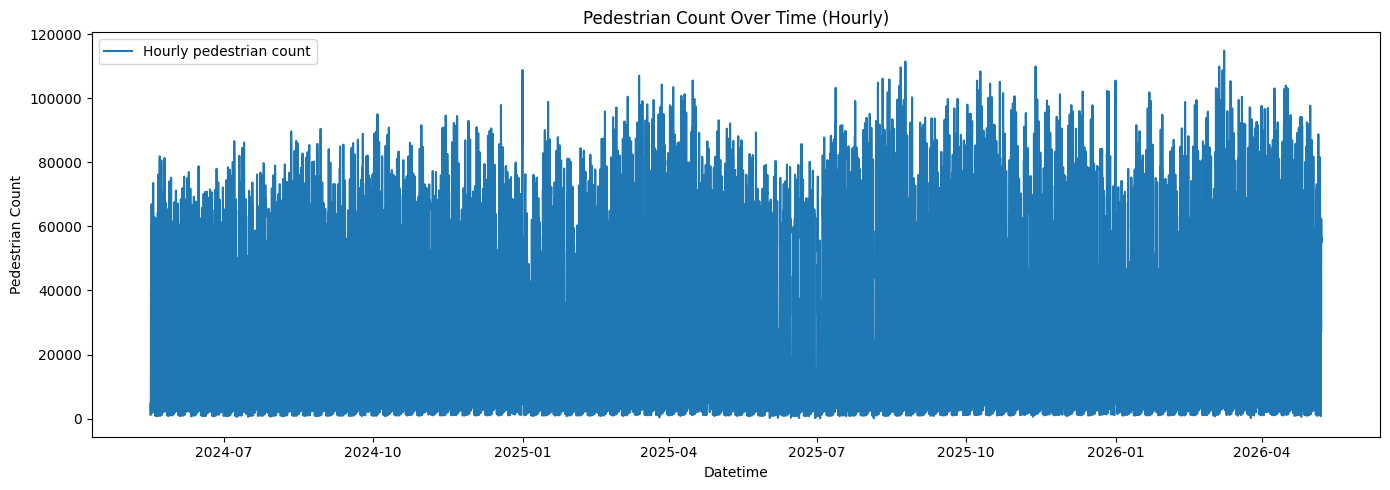

In [78]:
# Plot pedestrian counts over time.
plt.figure(figsize=(14, 5))
plt.plot(
    model_df["datetime_hour"],
    model_df["pedestriancount"],
    label="Hourly pedestrian count"
)

plt.title("Pedestrian Count Over Time (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Pedestrian Count")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Average Pedestrian Count By Day Of Week

The day-of-week summary was checked to see if there may also be other variables like work patterns, shopping activities, or weekend behaviours that might have influenced the pedestrian demand. Also checks whether the day of the week should be considered an important time-based feature for later modelling <a href="#fn-35">[35]</a> <a href="#fn-37">[37]</a>.

From the plot, it does seem like the weekdays tend to be relatively high along with Saturdays, whereas Mondays and Sundays tend to have low pedestrian demands. Monday might be low despite being a normal workday for the average Australians might be due to the influence of public holidays, and Sunday being low is due to most people not working on Sunday, since businesses would usually pay a high penalty rate. This further suggests that the CBD pedestrian pattern is linked to weekday economic and commuter activity, not just climate variables.

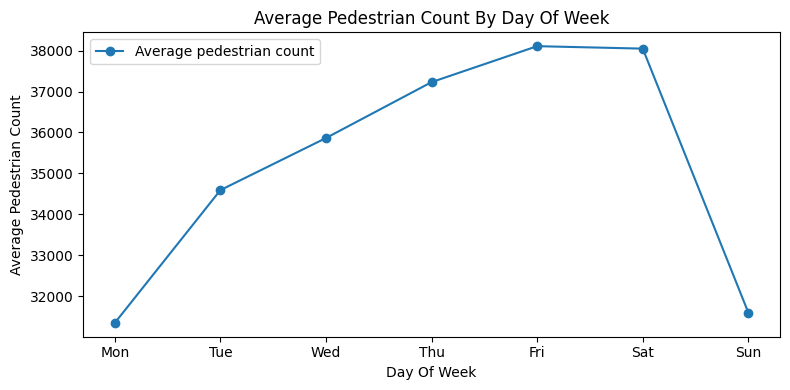

In [79]:
# Create a day-of-week column.
model_df["day_of_week"] = model_df[
    "datetime_hour"
].dt.dayofweek

# Group by day of week.
dow_pattern = model_df.groupby("day_of_week")[
    "pedestriancount"
].mean()

# Plot the day-of-week pattern.
plt.figure(figsize=(8, 4))
plt.plot(
    dow_pattern.index,
    dow_pattern.values,
    marker="o",
    label="Average pedestrian count"
)

plt.title("Average Pedestrian Count By Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Pedestrian Count")
plt.xticks(
    ticks=range(7),
    labels=[
        "Mon", "Tue", "Wed",
        "Thu", "Fri", "Sat", "Sun"
    ]
)
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Distributions Of Variables

Checking for distribution to see whether it's symmetric, skewed, or multi-modal. This is useful because skewed variables, extreme values, or unusual distributions can influence how the model learns from the data <a href="#fn-38">[38]</a>.

* pedestriancount appears unimodal and right-skewed.
* airtemperature appears unimodal with a slight right skew.
* relativehumidity appears unimodal with a slight left skew.
* atmosphericpressure appears unimodal and slightly left-skewed.
* averagewindspeed appears unimodal and right-skewed.
* gustwindspeed appears unimodal and right-skewed.
* averagewinddirection appears roughly unimodal and mostly symmetric.
* pm25 appears unimodal and right-skewed.
* pm10 appears unimodal and right-skewed, similar to pm25.
* noise appears unimodal and fairly symmetric.

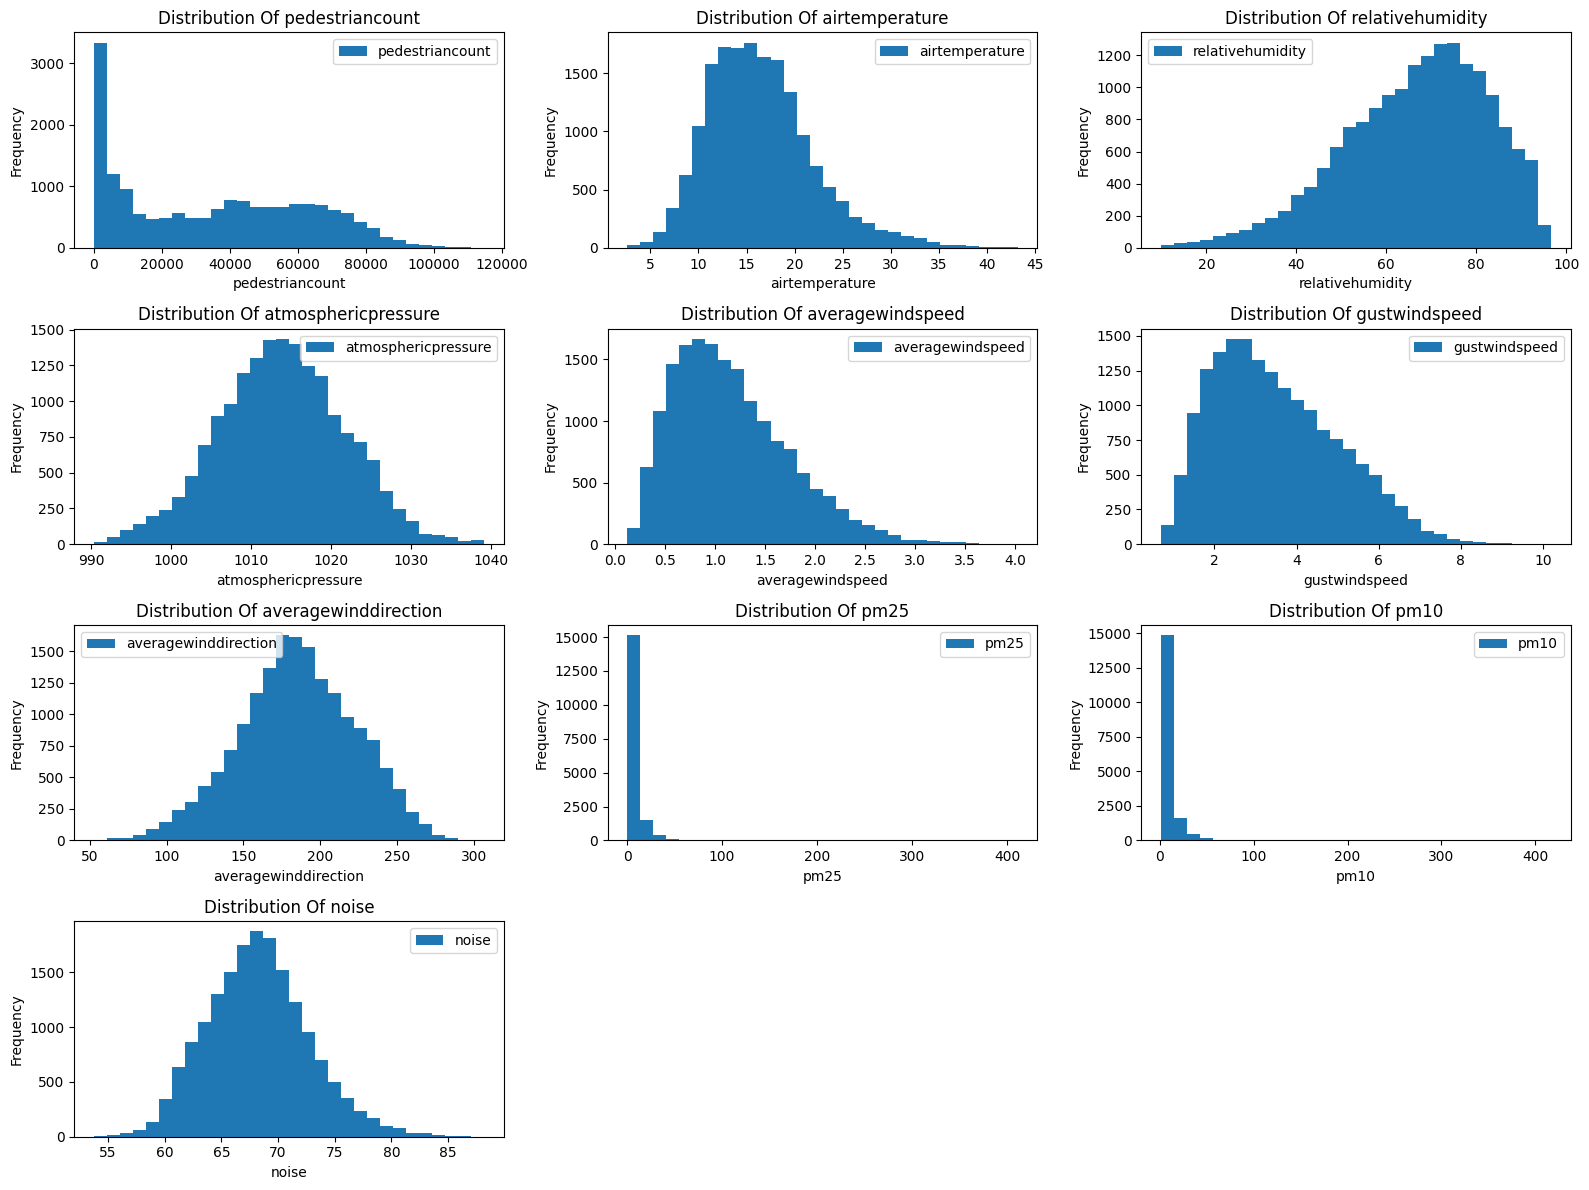

In [80]:
# Store numeric columns.
numeric_cols = model_df.select_dtypes(
    include=["int32", "int64", "float64"]
).columns.drop(
    ["day_of_week"],
    errors="ignore"
)

# Create subplot layout.
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 12)
)

axes = axes.flatten()

# Plot histogram for each numeric column.
for i, col in enumerate(numeric_cols):
    axes[i].hist(
        model_df[col],
        bins=30,
        label=col
    )
    axes[i].set_title(f"Distribution Of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Remove empty subplots.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 6.4 Correlation Matrix

Checking the correlation matrix is a quick way to see which climate variables might have the strongest relationship with pedestrian demand, which does seem like they have some influence on the target variable from the results. This is mainly to show whether the relationship is positive or negative, even though correlation does not prove causation <a href="#fn-39">[39]</a>.

- noise has the strongest positive correlation with pedestrian count, followed by gustwindspeed, airtemperature, averagewindspeed, and averagewinddirection. This suggests that pedestrian activity tends to increase when these variables increase.
- relativehumidity has the strongest negative correlation with pedestrian count, while pm10, pm25, and atmosphericpressure have weaker negative relationships. This suggests that pedestrian activity tends to decrease when these variables increase.

This suggests that climate variables do play a role in influencing the pedestrian demand, but there are other influences as well as discovered from previous plots. But the goal for this task is to understand how climate variables affect pedestrian demands.

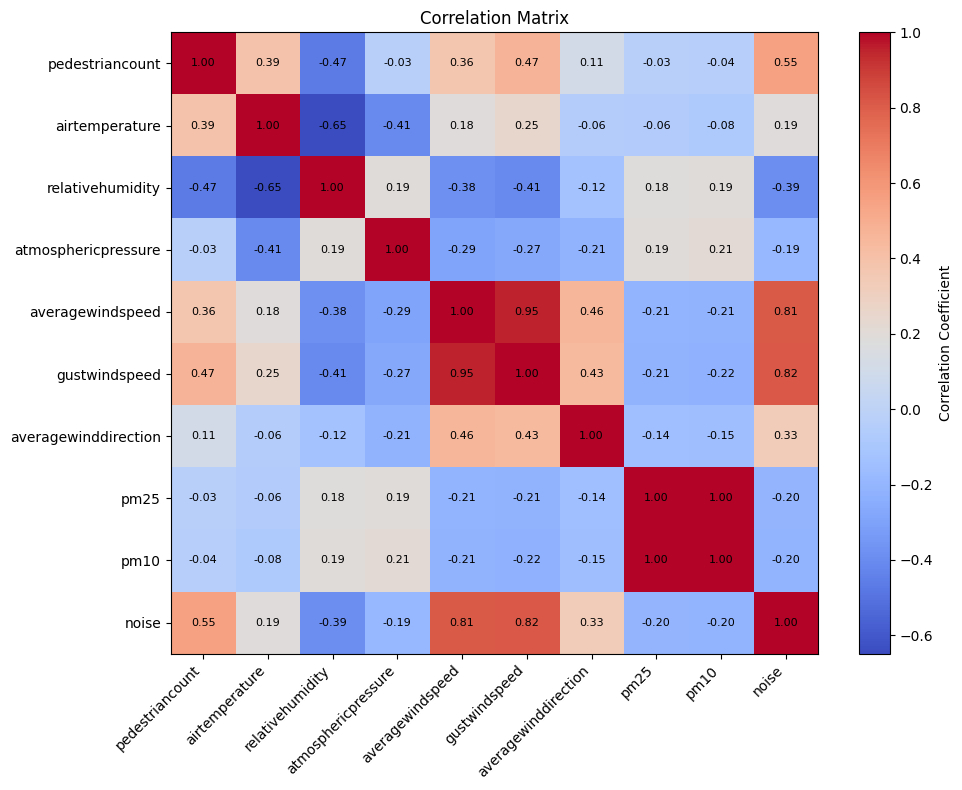

pedestriancount         1.000000
noise                   0.551746
gustwindspeed           0.465607
airtemperature          0.392074
averagewindspeed        0.363512
averagewinddirection    0.114771
atmosphericpressure    -0.033322
pm25                   -0.033755
pm10                   -0.037605
relativehumidity       -0.465763
Name: pedestriancount, dtype: float64


In [81]:
# Calculate the correlation matrix.
corr_matrix = model_df[numeric_cols].corr()

# Plot the correlation matrix.
plt.figure(figsize=(10, 8))
im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    aspect="auto"
)

cbar = plt.colorbar(im)
cbar.set_label("Correlation Coefficient")

plt.xticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Correlation Matrix")

# Add values inside each cell.
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

# Print the correlation values with pedestrian count.
print(corr_matrix["pedestriancount"].sort_values(ascending=False))

## 7. Time Series Analysis

This section is necessary as exploratory data analysis alone is not enough to check a time series dataset. Hence, time series analysis is necessary to help uncover more trends, seasonality, repeated lag dependence, and stationarity <a href="#fn-36">[36]</a>.

### 7.1 Pedestrian Count Over Time (24-Hour Rolling Mean)

The previous plot with the pedestrian count over time was noisy, so smoothing over 24 hours may help reveal more patterns of pedestrian activity without the hour-to-hour volatility <a href="#fn-40">[40]</a>.

From the plot, it became much more obvious that the highest peaks were during New Year's, where pedestrian visit the Melbourne CBD to see the fireworks, and confirms what has been previously discussed. There does seem to be a slightly increasing trend, which suggests that the influence of COVID-19 is still recovering.

In [82]:
# Create the hourly target series.
ts = model_df.set_index("datetime_hour")[
    "pedestriancount"
].sort_index()

# Check the first few rows.
print(ts.head())

datetime_hour
2024-05-17 00:00:00    4605
2024-05-17 01:00:00    2848
2024-05-17 02:00:00    1717
2024-05-17 03:00:00    1320
2024-05-17 04:00:00    1108
Name: pedestriancount, dtype: int64


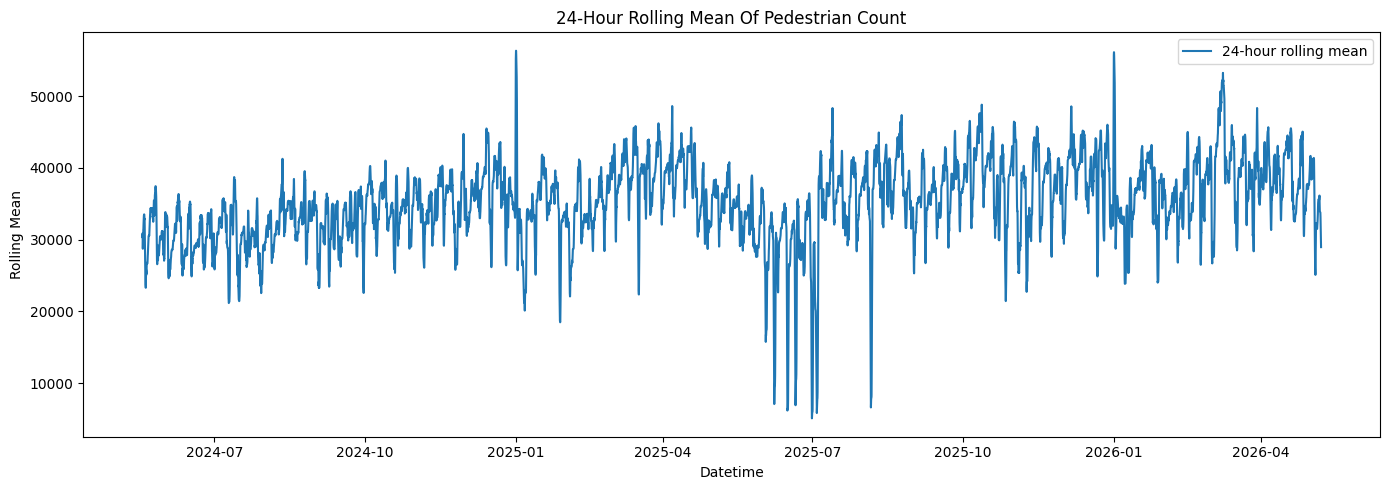

In [83]:
# Calculate the 24-hour rolling mean.
rolling_mean_24 = ts.rolling(24).mean()

# Plot the rolling mean only.
plt.figure(figsize=(14, 5))
plt.plot(
    rolling_mean_24,
    label="24-hour rolling mean"
)

plt.title("24-Hour Rolling Mean Of Pedestrian Count")
plt.xlabel("Datetime")
plt.ylabel("Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Seasonal Pattern (24-Hour Cycle)

Seasonal decomposition is necessary because hourly pedestrian demand is expected to have a strong daily cycle, so checking the seasonal component can help check how the typical hour of the day affects pedestrian activity. Since people usually move through the city at different levels during the morning, workday, evening, and late night, this step helps show whether the hour of the day is a factor in pedestrian demand <a href="#fn-41">[41]</a>.

From the plot, it is clear that the seasonal effect is strongly negative at night and becomes strongly positive during the workday, especially the peak at 5 PM, when most people finish work and are looking to go home. The lowest tends to be around 3 AM, which is expected, since people tend to party late until 12 PM before heading home, and the other reason is that the city's pedestrian activities are very limited at that time. This plot further confirms that hour-of-day is a major driver of pedestrian demand, and there may be other variables influencing pedestrian demand.

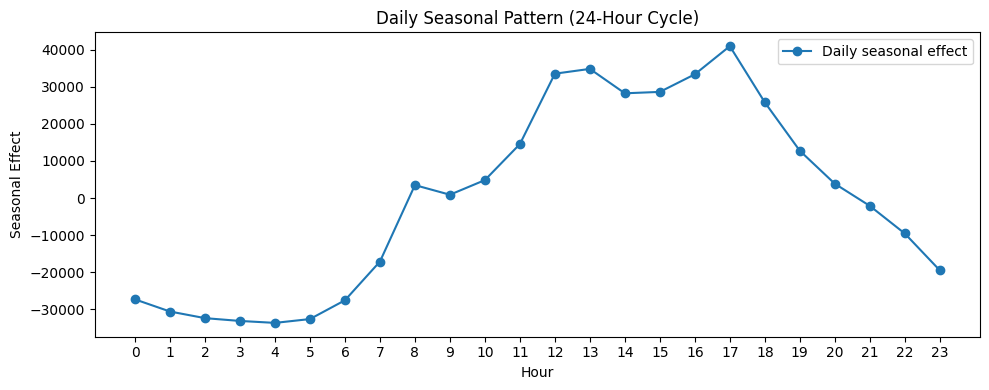

In [84]:
# Decompose the series using a 24-hour period.
decomp_24 = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

# Store one seasonal cycle and align it to the actual hours.
seasonal_24 = pd.Series(
    decomp_24.seasonal[:24].values,
    index=ts.index[:24].hour
)

# Sort by actual hour.
seasonal_24 = seasonal_24.sort_index()

# Plot the corrected daily seasonal pattern.
plt.figure(figsize=(10, 4))
plt.plot(
    seasonal_24.index,
    seasonal_24.values,
    marker="o",
    label="Daily seasonal effect"
)

plt.title("Daily Seasonal Pattern (24-Hour Cycle)")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Autocorrelation Of Pedestrian Count

Checking for autocorrelation is important because it shows whether the current pedestrian demand depends on previous hours, and if strong dependence exists, then lag features will be very useful for forecasting <a href="#fn-42">[42]</a>.

From the plot, there appears to be a very strong repeating pattern at a regular interval, especially around daily cycles. This repeated structure applies not only on the daily level, but also appears to be on the weekly level as well, meaning daily and weekly lag features will be useful for predictions.

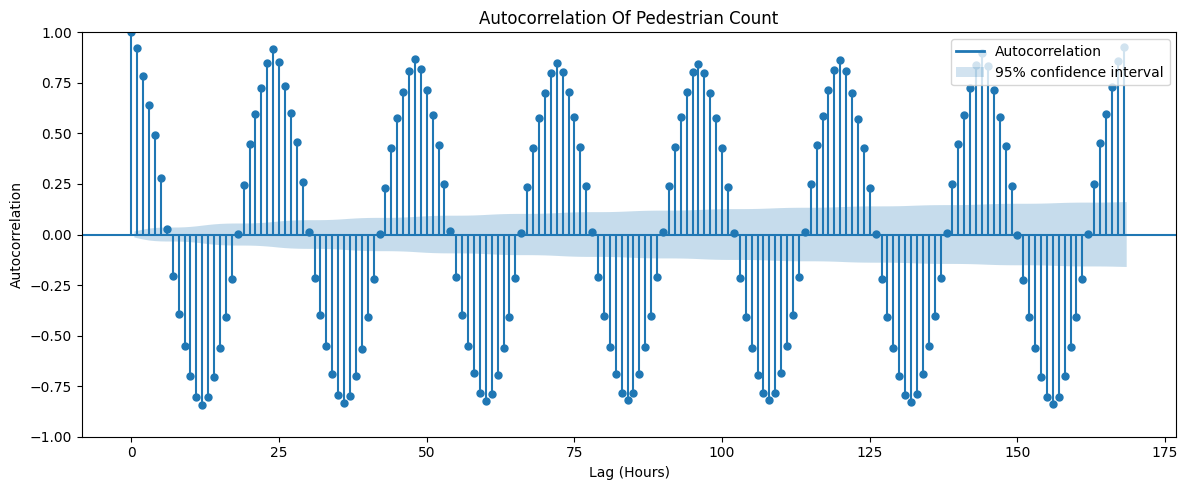

In [85]:
# Plot autocorrelation for one week of hourly lags.
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=168, ax=ax)

ax.set_title("Autocorrelation Of Pedestrian Count")
ax.set_xlabel("Lag (Hours)")
ax.set_ylabel("Autocorrelation")

# Add legend handles.
legend_handles = [
    Line2D([0], [0], color="C0", lw=2, label="Autocorrelation"),
    Patch(alpha=0.2, label="95% confidence interval")
]

ax.legend(handles=legend_handles, loc="upper right")
plt.tight_layout()
plt.show()

### 7.4 Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller Test checks whether the time series is statistically stationary in the unit-root sense, and while not necessary for deep learning modelling, it does provide some more understanding of the patterns underlying the merged dataset <a href="#fn-43">[43]</a>.

The result was that the p-value is extremely small and the test statistic is far below the critical values, hence, the null hypothesis of a unit root is rejected. This means that the time series dataset is statistically stationary enough to exhibit a learnable structure rather than behaving like a random walk, which basically means that it's not necessarily a random coin toss in layman's terms.

In [86]:
# Run the Augmented Dickey-Fuller test.
adf_result = adfuller(ts)

# Print the results.
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -12.559845121222684
p-value: 2.1144073042785164e-23
Critical Values:
1%: -3.430729124300733
5%: -2.861707558145591
10%: -2.5668591868779282


## 8. Feature Engineering

The feature engineering section is necessary because the current variables in the merged datasets may not necessarily be enough for a strong forecasting model, so doing feature engineering will create more useful variables that help capture other aspects of the datasets, like cyclical structures, recent history, and short-term trends <a href="#fn-44">[44]</a> <a href="#fn-45">[45]</a>.

### 8.1 Creating Time Features

Creating more calendar-based features is necessary because pedestrian activity depends on when that observation happened, as shown in previous plots. Hence, hours, day of week, month, and weekend status are all useful predictors. This step ensures the datetime_hour column is converted into its individual components <a href="#fn-45">[45]</a>.

The output shows that new time-based columns were added to the dataset. These include hour, day_of_week, month, and is_weekend.

In [87]:
# Create a copy for feature engineering.
features_df = model_df.copy()

# Extract calendar features.
features_df["hour"] = features_df["datetime_hour"].dt.hour
features_df["day_of_week"] = (
    features_df["datetime_hour"].dt.dayofweek
)
features_df["month"] = features_df["datetime_hour"].dt.month
features_df["is_weekend"] = (
    features_df["day_of_week"] >= 5
).astype(int)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour", "day_of_week", "month", 
            "is_weekend"
        ]
    ].head()
)

        datetime_hour  hour  day_of_week  month  is_weekend
0 2024-05-17 00:00:00     0            4      5           0
1 2024-05-17 01:00:00     1            4      5           0
2 2024-05-17 02:00:00     2            4      5           0
3 2024-05-17 03:00:00     3            4      5           0
4 2024-05-17 04:00:00     4            4      5           0


### 8.2 Creating Cyclical Time Features

Cyclical encoding is necessary since time variables are cyclical and not linear, like a clock. If we're talking just normal values like 0 and 23, these two values are quite far apart, but it's not, since it's time and there's only 1 hour difference. Using sine and cosine preserves that circular structure. This step ensures that the time variables are cyclical and prevents the models from learning misleading distances between values at the edge of a cycle <a href="#fn-46">[46]</a>.

The output shows that new cyclical time features were created, including hour_sin, hour_cos, dow_sin, dow_cos, month_sin, and month_cos.

In [88]:
# Hour and day of week are cyclical, not linear.
# Create cyclical hour features.
features_df["hour_sin"] = np.sin(
    2 * np.pi * features_df["hour"] / 24
)
features_df["hour_cos"] = np.cos(
    2 * np.pi * features_df["hour"] / 24
)

# Create cyclical day-of-week features.
features_df["dow_sin"] = np.sin(
    2 * np.pi * features_df["day_of_week"] / 7
)
features_df["dow_cos"] = np.cos(
    2 * np.pi * features_df["day_of_week"] / 7
)

# Convert cyclical month features.
features_df["month_sin"] = np.sin(
    2 * np.pi * features_df["month"] / 12
)
features_df["month_cos"] = np.cos(
    2 * np.pi * features_df["month"] / 12
)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour_sin", "hour_cos",
            "dow_sin", "dow_cos", "month_sin", 
            "month_cos"
        ]
    ].head()
)

        datetime_hour  hour_sin  hour_cos   dow_sin   dow_cos  month_sin  \
0 2024-05-17 00:00:00  0.000000  1.000000 -0.433884 -0.900969        0.5   
1 2024-05-17 01:00:00  0.258819  0.965926 -0.433884 -0.900969        0.5   
2 2024-05-17 02:00:00  0.500000  0.866025 -0.433884 -0.900969        0.5   
3 2024-05-17 03:00:00  0.707107  0.707107 -0.433884 -0.900969        0.5   
4 2024-05-17 04:00:00  0.866025  0.500000 -0.433884 -0.900969        0.5   

   month_cos  
0  -0.866025  
1  -0.866025  
2  -0.866025  
3  -0.866025  
4  -0.866025  


### 8.3 Creating Cyclical Wind Direction Features

Wind direction is also circular, being 360 degrees, meaning 0 and 359 degrees are almost the same direction. So wind direction must also be converted to cyclical for a continuous form, and ensure consistency with treatments of cyclical variables like time <a href="#fn-46">[46]</a>.

The output shows that two new features were created, wind_dir_sin and wind_dir_cos.

In [89]:
# Convert wind direction into cyclical form.
features_df["wind_dir_sin"] = np.sin(
    2 * np.pi * features_df["averagewinddirection"] / 360
)
features_df["wind_dir_cos"] = np.cos(
    2 * np.pi * features_df["averagewinddirection"] / 360
)

# Check the result.
print(
    features_df[
        [
            "averagewinddirection",
            "wind_dir_sin",
            "wind_dir_cos"
        ]
    ].head()
)

   averagewinddirection  wind_dir_sin  wind_dir_cos
0            181.250000     -0.021815     -0.999762
1            145.115385      0.571926     -0.820305
2            142.655172      0.606611     -0.794999
3            132.642857      0.735591     -0.677426
4            148.285714      0.525684     -0.850680


### 8.4 Creating Lag Features

Lag features are important, as indicated by the autocorrelation plot, since pedestrian demand is highly dependent on recent history based on the autocorrelation plot <a href="#fn-47">[47]</a> <a href="#fn-48">[48]</a>.

The features lag_1, lag_24, and lag_168 capture the previous hour, previous day, and previous week at the same hour. This does create missing values since there wasn't recent information to populate the lag columns for specific rows, which will be dealt with. Like the very first row having a missing value for lag_1, because there wasn't a previous row to populate that value.

In [90]:
# Create lagged pedestrian count features.
features_df["lag_1"] = (
    features_df["pedestriancount"].shift(1)
)

features_df["lag_24"] = (
    features_df["pedestriancount"].shift(24)
)

features_df["lag_168"] = (
    features_df["pedestriancount"].shift(168)
)

# Check the result.
print(
    features_df[
        [
            "lag_1", "lag_24", "lag_168"
        ]
    ].head(25)
)

      lag_1  lag_24  lag_168
0       NaN     NaN      NaN
1    4605.0     NaN      NaN
2    2848.0     NaN      NaN
3    1717.0     NaN      NaN
4    1320.0     NaN      NaN
5    1108.0     NaN      NaN
6    2534.0     NaN      NaN
7    7820.0     NaN      NaN
8   18065.0     NaN      NaN
9   39447.0     NaN      NaN
10  36425.0     NaN      NaN
11  37300.0     NaN      NaN
12  42989.0     NaN      NaN
13  60083.0     NaN      NaN
14  59930.0     NaN      NaN
15  47839.0     NaN      NaN
16  45804.0     NaN      NaN
17  56617.0     NaN      NaN
18  66916.0     NaN      NaN
19  54165.0     NaN      NaN
20  43530.0     NaN      NaN
21  29146.0     NaN      NaN
22  28319.0     NaN      NaN
23  23767.0     NaN      NaN
24  16442.0  4605.0      NaN


### 8.5 Creating Rolling Features

Rolling features summarise recent pedestrian counts rather than relying on a single observation for a datapoint, allowing the model to capture the short-term trend and help smooth the short-term noise <a href="#fn-47">[47]</a>.

Some new predictors were added, like rolling_mean_24, which summarises the previous 24 hours, while rolling_mean_168 summarises the previous week. And as expected, similar to lag features but not the same, the first rows are missing values since the rolling window cannot be calculated until enough history exists. 

In [91]:
# Create rolling mean features from past counts.
features_df["rolling_mean_24"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(24)
    .mean()
)

features_df["rolling_mean_168"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Check the result.
print(
    features_df[
        [
            "rolling_mean_24", "rolling_mean_168"
        ]
    ].head(25)
)

    rolling_mean_24  rolling_mean_168
0               NaN               NaN
1               NaN               NaN
2               NaN               NaN
3               NaN               NaN
4               NaN               NaN
5               NaN               NaN
6               NaN               NaN
7               NaN               NaN
8               NaN               NaN
9               NaN               NaN
10              NaN               NaN
11              NaN               NaN
12              NaN               NaN
13              NaN               NaN
14              NaN               NaN
15              NaN               NaN
16              NaN               NaN
17              NaN               NaN
18              NaN               NaN
19              NaN               NaN
20              NaN               NaN
21              NaN               NaN
22              NaN               NaN
23              NaN               NaN
24          30364.0               NaN


### 8.6 Removing NA Rows

This step removes the rows with missing values created from the lag and rolling features at the beginning of the ordered merged dataset, since they cannot be used as they are incomplete predictor information. By removing these rows, the dataset lost a part of the early period as a trade-off in the pipeline, which is reasonable considering the dataset is being updated in real-time, so there will be more data points to use in the future, hence, negligible <a href="#fn-48">[48]</a>.

The output shows that all rows with missing values were removed, and the dataset was reset into a clean index.

In [92]:
# Remove rows with NAs.
features_df = features_df.dropna().reset_index(drop=True)

# Check the result.
print(features_df.info())
print(features_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17128 entries, 0 to 17127
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17128 non-null  datetime64[ns]
 1   pedestriancount       17128 non-null  int64         
 2   airtemperature        17128 non-null  float64       
 3   relativehumidity      17128 non-null  float64       
 4   atmosphericpressure   17128 non-null  float64       
 5   averagewindspeed      17128 non-null  float64       
 6   gustwindspeed         17128 non-null  float64       
 7   averagewinddirection  17128 non-null  float64       
 8   pm25                  17128 non-null  float64       
 9   pm10                  17128 non-null  float64       
 10  noise                 17128 non-null  float64       
 11  day_of_week           17128 non-null  int32         
 12  hour                  17128 non-null  int32         
 13  month           

### 8.7 Removing Unnecessary Features

Since the cyclical variables were created, the original raw cyclical variables have become redundant. So removing these variables helps reduce feature duplication and makes the modelling easier and cleaner <a href="#fn-23">[23]</a> <a href="#fn-24">[24]</a>.

The averagewinddirection, hour, day_of_week, and month columns are dropped. Resulting in 24 columns, including the target pedestrian count, selected climate variables, is_weekend, cyclical encodings, lag features, and rolling means. The datetime_hour is temporarily kept, but will be removed later on as well.

In [93]:
# Drop raw columns that now have cyclical replacements.
features_df = features_df.drop(
    columns=[
        "averagewinddirection",
        "hour",
        "day_of_week",
        "month",
    ]
)

# Reorder the columns into a cleaner structure.
features_df = features_df[
    [
        "datetime_hour",
        "pedestriancount",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "pm25",
        "pm10",
        "noise",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
        "wind_dir_sin",
        "wind_dir_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_mean_24",
        "rolling_mean_168",
    ]
]

# Check the result.
print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17128 entries, 0 to 17127
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime_hour        17128 non-null  datetime64[ns]
 1   pedestriancount      17128 non-null  int64         
 2   airtemperature       17128 non-null  float64       
 3   relativehumidity     17128 non-null  float64       
 4   atmosphericpressure  17128 non-null  float64       
 5   averagewindspeed     17128 non-null  float64       
 6   gustwindspeed        17128 non-null  float64       
 7   pm25                 17128 non-null  float64       
 8   pm10                 17128 non-null  float64       
 9   noise                17128 non-null  float64       
 10  is_weekend           17128 non-null  int64         
 11  hour_sin             17128 non-null  float64       
 12  hour_cos             17128 non-null  float64       
 13  dow_sin              17128 non-

## 9. Preparing Train/Val/Test Splits

Preparing the splits is necessary for training a forecasting model, so that the future periods are evaluated, and not on randomly selected time periods. Hence, splitting the dataset based on time is important so that the model being trained on the past can predict the future, like in real-world scenarios <a href="#fn-49">[49]</a>.

### 9.1 Splitting The Data By Time

Chronological splitting in time-series forecasting is to prevent leaking future information into the training process. For example is if random splitting were to be used, then a model can be trained on data points in 2026, but is tested on a time period in 2025. Hence, the validation and test set must be later, and the training set must be the past, as shown here <a href="#fn-49">[49]</a>.

The split for training, validation and testing is 80:10:10 to ensure that there are enough data points used for training, with enough data points to perform validation and testing. Deep learning tends to require a large number of data points, so using this split ratio prevents underfitting <a href="#fn-50">[50]</a>.

The output confirms that the data was split chronologically, with the training data coming first, followed by validation and testing data.

In [94]:
# Set the split sizes (80:10:10).
train_size = int(len(features_df) * 0.8)
val_size = int(len(features_df) * 0.1)

# Split the data in chronological order.
train_df = features_df.iloc[:train_size].copy()
val_df = features_df.iloc[
    train_size:train_size + val_size
].copy()
test_df = features_df.iloc[
    train_size + val_size:
].copy()

# Check the shapes.
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(13702, 24)
(1712, 24)
(1714, 24)


In [95]:
# Checking The Split Ranges.
print("Train range:")
print(train_df["datetime_hour"].min())
print(train_df["datetime_hour"].max())

print("\nValidation range:")
print(val_df["datetime_hour"].min())
print(val_df["datetime_hour"].max())

print("\nTest range:")
print(test_df["datetime_hour"].min())
print(test_df["datetime_hour"].max())

Train range:
2024-05-24 00:00:00
2025-12-15 21:00:00

Validation range:
2025-12-15 22:00:00
2026-02-25 05:00:00

Test range:
2026-02-25 06:00:00
2026-05-07 15:00:00


### 9.2 Separating Features And Target

This step is necessary to separate the predictor inputs X and the output target y. This is necessary because the model needs to know which columns are used as inputs and which column it needs to predict <a href="#fn-51">[51]</a>.

The target is set to pedestriancount, which is the variable the model is trying to predict. The datetime column is excluded from the features since the chronological splitting is completed, so this leaves 22 predictor columns for each split, as shown in the shapes output.

In [96]:
# Store the target column name.
target_col = "pedestriancount"

# Store the feature column names.
feature_cols = [
    col for col in features_df.columns
    if col not in ["datetime_hour", target_col]
]

# Create X and y for each split.
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check the shapes.
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(13702, 22) (13702,)
(1712, 22) (1712,)
(1714, 22) (1714,)


### 9.3 Scaling The Features

Scaling the features is necessary because the predictor variables are measured on different scales. For example, temperature, humidity, air pressure, wind speed, pollution values, and lagged pedestrian counts all have different ranges. Hence, needs to be standardised so that the variables are unitless, allowing the variables to be able to directly compared <a href="#fn-52">[52]</a>.

Standardisation basically sets the predictors to have a mean of 0 and a standard deviation of 1. This allows faster convergence when all the input features are on the same scale, preventing feature dominance due to differences in magnitudes, and is generally more stable <a href="#fn-52">[52]</a>.

In [97]:
# Create the scaler.
scaler = StandardScaler()

# Fit on training features only.
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test features.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check the shapes.
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled[:5])

(13702, 22)
(1712, 22)
(1714, 22)
[[-1.10172123e+00  1.14777440e+00  1.44563444e+00 -1.51401172e+00
  -1.54625740e+00  1.70744733e+00  1.65587318e+00 -5.72880101e-01
  -6.34847166e-01 -7.83154794e-05  1.41447318e+00 -6.08408858e-01
  -1.27473012e+00  1.04524307e+00 -1.14803023e+00  7.83983100e-01
  -6.05324657e-01 -8.87358123e-01 -1.12478749e+00 -1.10879206e+00
  -7.94816827e-02 -1.09501575e+00]
 [-1.19512768e+00  1.17835581e+00  1.41129169e+00 -1.17985853e+00
  -1.41442047e+00  1.78751087e+00  1.72142606e+00 -7.72091360e-01
  -6.34847166e-01  3.65928845e-01  1.36628262e+00 -6.08408858e-01
  -1.27473012e+00  1.04524307e+00 -1.14803023e+00  3.61327867e-01
  -8.18149782e-01 -1.09708779e+00 -1.19449108e+00 -1.17380396e+00
  -7.39813434e-02 -1.09445057e+00]
 [-1.29764938e+00  1.20732469e+00  1.41920334e+00 -5.46205069e-01
  -1.16722621e+00  1.48714981e+00  1.44981864e+00 -1.10732169e+00
  -6.34847166e-01  7.06993223e-01  1.22499504e+00 -6.08408858e-01
  -1.27473012e+00  1.04524307e+00 -1.1

## 10. Deep Learning — Pedestrian Count Forecasting

This section covers the deep learning component of the project. The goal is to build 
and compare recurrent neural network models that can forecast hourly pedestrian counts 
in Melbourne CBD using climate features and engineered time-series inputs.

Deep learning models, specifically recurrent neural network architectures like LSTM 
and GRU, are well suited for this task because pedestrian demand is a sequential, 
time-dependent process <a href="#fn-53">[53]</a>. Unlike traditional regression 
models, recurrent networks can learn temporal patterns across multiple time steps, 
making them appropriate for hourly forecasting tasks with lag dependencies 
<a href="#fn-54">[54]</a>.

### 10.2 Setting Random Seeds for Reproducibility

A fixed random seed is set across all relevant libraries before any model is built or 
trained. Deep learning models initialise their weights randomly and apply random 
dropout masks during training, which means that results can differ between runs 
without a fixed seed <a href="#fn-55">[55]</a>. By setting the same seed across 
Python, NumPy, and TensorFlow, the outputs of this section are fully reproducible 
and will produce identical results on every run 
<a href="#fn-7">[7]</a> <a href="#fn-55">[55]</a>.

Additional environment variables TF_DETERMINISTIC_OPS and 
TF_DISABLE_SEGMENT_REDUCTION_OP_DETERMINISM_EXCEPTIONS are set to further enforce 
deterministic behaviour at the TensorFlow operation level 
<a href="#fn-55">[55]</a>. The student ID was used as the seed value for consistency 
with the random seed convention used earlier in this notebook 
<a href="#fn-7">[7]</a>.

In [98]:
SEED = 224120439

# 1. Force single thread to eliminate CPU non-determinism
os.environ["PYTHONHASHSEED"]        = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]  = "1"
os.environ["TF_DISABLE_SEGMENT_REDUCTION_OP_DETERMINISM_EXCEPTIONS"] = "1"

# 2. Seed all libraries
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# 3. Force deterministic operations
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass  # silently skip if not supported on this system

print(f"Random seed set to: {SEED}")
print(f"TF version: {tf.__version__}")

Random seed set to: 224120439
TF version: 2.20.0


### 10.3 Creating Input Sequences

Before training a recurrent neural network, the data must be reshaped into 
three-dimensional sequences. Each sequence consists of a fixed-length window of past 
hourly observations that the model uses to predict the next hour's pedestrian count 
<a href="#fn-56">[56]</a>.

A sequence length of 24 was chosen to capture one full day cycle of hourly patterns. 
This is a natural choice given that pedestrian demand follows a strong 24-hour rhythm, 
as confirmed by the seasonal decomposition and autocorrelation analysis in earlier 
sections <a href="#fn-35">[35]</a> <a href="#fn-42">[42]</a>. Additionally, since lag 
features covering 24 hours, 7 days, and rolling means are already included as input 
features, extending the sequence window further would introduce redundancy without 
meaningful benefit <a href="#fn-47">[47]</a> <a href="#fn-48">[48]</a>.

Each input sample X has the shape (24, 22), representing 24 consecutive hours across 
22 engineered features. The corresponding target y is the pedestrian count at the 
following hour, making this a one-step-ahead forecasting setup 
<a href="#fn-56">[56]</a>. The output shapes confirm the split sizes — 13,774 
training samples, 1,700 validation samples, and 1,702 test samples.

In [99]:
sequence_length = 24 

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i - seq_length:i])
        y_seq.append(y.iloc[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val,   sequence_length)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test,  sequence_length)

print("Train shape:", X_train_seq.shape)
print("Val shape:",   X_val_seq.shape)
print("Test shape:",  X_test_seq.shape)

Train shape: (13678, 24, 22)
Val shape: (1688, 24, 22)
Test shape: (1690, 24, 22)


### 10.4 Model Architectures

Three recurrent neural network architectures were built and compared to identify the 
most effective model for this forecasting task. Comparing multiple architectures 
allows for evidence-based model selection rather than relying on a single approach 
<a href="#fn-53">[53]</a> <a href="#fn-57">[57]</a>.

All three models share the same output structure — a Dense(32) hidden layer followed 
by a Dense(1) output layer for regression — and are compiled with the Adam optimiser 
and Mean Squared Error loss, which is standard for continuous value regression 
forecasting tasks <a href="#fn-58">[58]</a>. Mean Absolute Error is tracked as an 
interpretable secondary metric during training <a href="#fn-59">[59]</a>.

The three architectures evaluated are:
- **Baseline LSTM**: A single LSTM layer with 64 units serving as the reference model 
  to establish a performance baseline.
- **Stacked LSTM**: Two LSTM layers in sequence for deeper temporal pattern learning.
- **GRU**: A more parameter-efficient alternative to LSTM with a simplified gate 
  structure.

#### 10.4.1 Baseline LSTM

The baseline model uses a single LSTM layer with 64 units. LSTM networks are designed 
to address the vanishing gradient problem found in standard recurrent networks, 
allowing them to retain information across longer time sequences 
<a href="#fn-54">[54]</a>. At each time step, the LSTM uses three gates — an input 
gate, a forget gate, and an output gate — to decide what information to keep, discard, 
or pass forward <a href="#fn-54">[54]</a>.

A Dropout layer with a rate of 0.2 is applied after the LSTM to regularise the model 
by randomly deactivating 20% of neurons during each training step, reducing the risk 
of overfitting <a href="#fn-60">[60]</a>. This model has 24,385 total trainable 
parameters, which is appropriate for the training set size of approximately 13,774 
samples.

In [100]:
def build_lstm_baseline(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_baseline = build_lstm_baseline(
    (X_train_seq.shape[1], X_train_seq.shape[2])
)
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

#### 10.4.2 Stacked LSTM

The stacked model adds a second LSTM layer on top of the first. The first LSTM layer 
uses return_sequences=True, meaning it outputs the full sequence of hidden states at 
every time step rather than just the final one. This full sequence is then passed as 
input to the second LSTM layer, which compresses it into a single final hidden state 
<a href="#fn-54">[54]</a>.

This design allows the model to learn more abstract temporal representations across 
multiple levels of processing — the first layer captures low-level hourly patterns, 
while the second layer can learn higher-order dependencies across those patterns 
<a href="#fn-53">[53]</a>. Dropout is applied after each LSTM layer to maintain 
regularisation <a href="#fn-60">[60]</a>. This model has 35,777 total trainable 
parameters, making it the most complex of the three architectures compared.

In [101]:
def build_lstm_stacked(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_stacked = build_lstm_stacked(
    (X_train_seq.shape[1], X_train_seq.shape[2])
)
model_stacked.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,777 (139.75 KB)

 Trainable params: 35,777 (139.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 10.4.3 GRU (Gated Recurrent Unit)

The GRU model replaces the LSTM unit with a GRU layer of equal size. GRU simplifies 
the LSTM architecture by combining the input and forget gates into a single update 
gate, and adding a reset gate, resulting in only two gates overall instead of three 
<a href="#fn-61">[61]</a>. This reduction in gate complexity leads to fewer 
parameters — 19,009 total — making the GRU the most lightweight of the three 
architectures.

GRU is included as an alternative because empirical research has shown it often 
performs comparably or better than LSTM on time-series forecasting tasks, 
particularly on datasets that are not large enough to fully justify the additional 
capacity of LSTM <a href="#fn-61">[61]</a> <a href="#fn-62">[62]</a>. This 
comparison tests whether that finding holds for this urban pedestrian forecasting 
task.

In [102]:
def build_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_gru = build_gru(
    (X_train_seq.shape[1], X_train_seq.shape[2])
)
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

### 10.5 Model Training

All three models are trained using identical configurations to ensure a fair 
comparison between architectures. The training setup includes the following design 
choices <a href="#fn-58">[58]</a>:

- **Epochs**: A maximum of 50 epochs was set to allow sufficient learning time, with 
  callbacks responsible for halting training early when appropriate 
  <a href="#fn-58">[58]</a>.
- **Batch size**: A batch size of 64 was selected as a balance between training 
  stability and computational speed. Larger batch sizes provide more stable gradient 
  estimates per update compared to smaller ones <a href="#fn-58">[58]</a>.
- **EarlyStopping**: Monitors validation loss with a patience of 10 epochs, halting 
  training if no improvement is seen for 10 consecutive epochs. The 
  restore_best_weights=True parameter ensures the final model retains the weights 
  from its best validation epoch rather than the last epoch 
  <a href="#fn-63">[63]</a>.
- **ReduceLROnPlateau**: Halves the learning rate when validation loss has not 
  improved for 5 consecutive epochs, with a minimum learning rate floor of 1e-6. 
  This allows finer weight adjustments as the model approaches convergence rather 
  than overshooting the optimal solution <a href="#fn-63">[63]</a>.

The validation set is used exclusively for monitoring during training and is never 
used to update model weights, preserving the integrity of the chronological train, 
validation, and test split <a href="#fn-49">[49]</a>.

In [103]:
def get_callbacks():
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,              # increased from 5 — prevents premature stopping
        restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,               # halve LR when stuck
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    return [early_stop, reduce_lr]

# Train all three models
history_baseline = model_baseline.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=64,
    callbacks=get_callbacks(), verbose=1
)

history_stacked = model_stacked.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=64,
    callbacks=get_callbacks(), verbose=1
)

history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=64,
    callbacks=get_callbacks(), verbose=1
)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1934864256.0000 - mae: 34643.1523 - val_loss: 2055684352.0000 - val_mae: 36185.8594 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1918938240.0000 - mae: 34412.9102 - val_loss: 2032596352.0000 - val_mae: 35865.4023 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1890875520.0000 - mae: 34005.0430 - val_loss: 1997007616.0000 - val_mae: 35365.8984 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1851560960.0000 - mae: 33456.1953 - val_loss: 1950329728.0000 - val_mae: 34755.6250 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1802313728.0000 - mae: 32835.7695 - val_loss: 1894233728.0000 - val_mae: 34088.4688 - learning_rate: 0.0010
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1745453824.0000 - mae: 32181.2578 - val_loss: 1830577024.0000 - val_mae: 33408.3359 - learning_rate

### 10.6 Saving Trained Models

The three trained models are saved to disk immediately after training. This ensures 
that the evaluation results, plots, and metrics produced in subsequent cells are 
fully reproducible on every run without needing to retrain, since loading a saved 
model always produces identical predictions regardless of any residual random seed 
behaviour <a href="#fn-58">[58]</a>.

In [104]:
# Save all three trained models to disk
model_baseline.save("model_baseline.keras")
model_stacked.save("model_stacked.keras")
model_gru.save("model_gru.keras")

print("✓ model_baseline saved")
print("✓ model_stacked saved")
print("✓ model_gru saved")

✓ model_baseline saved
✓ model_stacked saved
✓ model_gru saved


### 10.7 Loading Saved Models

The saved models are loaded back from disk before evaluation begins. All subsequent 
evaluation, visualisation, and comparison cells use these loaded models, guaranteeing 
that the results in this notebook are consistent and reproducible on every run 
<a href="#fn-58">[58]</a>.

In [105]:
# Load all three models from disk
# This guarantees identical results on every run
model_baseline = tf.keras.models.load_model("model_baseline.keras")
model_stacked  = tf.keras.models.load_model("model_stacked.keras")
model_gru      = tf.keras.models.load_model("model_gru.keras")

print("✓ model_baseline loaded")
print("✓ model_stacked loaded")
print("✓ model_gru loaded")

✓ model_baseline loaded
✓ model_stacked loaded
✓ model_gru loaded


### 10.8 Model Evaluation

Each model is evaluated on the held-out test set using three standard regression 
metrics <a href="#fn-59">[59]</a>. The test set represents the final unseen time 
period and was not used at any point during training or validation, ensuring the 
evaluation reflects genuine out-of-sample forecasting performance 
<a href="#fn-49">[49]</a>.

- **MAE (Mean Absolute Error)**: The average absolute difference between predicted 
  and actual pedestrian counts. This is the most directly interpretable metric since 
  it is expressed in the same unit as the target variable — pedestrians per hour 
  <a href="#fn-59">[59]</a>.
- **RMSE (Root Mean Squared Error)**: Similar to MAE but penalises larger errors 
  more heavily due to the squaring operation. A substantially higher RMSE relative 
  to MAE indicates the presence of occasional large prediction errors 
  <a href="#fn-59">[59]</a>.
- **R² (Coefficient of Determination)**: Measures the proportion of variance in 
  pedestrian counts that the model successfully explains. A value of 1.0 represents 
  a perfect fit, while 0.0 means the model performs no better than simply predicting 
  the mean value <a href="#fn-59">[59]</a>.

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test).flatten()
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²:   {r2:.4f}")
    return y_pred, {"MAE": mae, "RMSE": rmse, "R2": r2}

pred_baseline, metrics_baseline = evaluate_model(model_baseline, X_test_seq, y_test_seq, "Baseline LSTM")
pred_stacked,  metrics_stacked  = evaluate_model(model_stacked,  X_test_seq, y_test_seq, "Stacked LSTM")
pred_gru,      metrics_gru      = evaluate_model(model_gru,      X_test_seq, y_test_seq, "GRU")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Baseline LSTM
  MAE:  5266.93
  RMSE: 8217.41
  R²:   0.9256
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Stacked LSTM
  MAE:  9086.58
  RMSE: 14430.51
  R²:   0.7705
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

GRU
  MAE:  4942.69
  RMSE: 7584.24
  R²:   0.9366


#### Evaluation Discussion

The GRU model achieved the best performance across all three metrics, with an MAE of 
4,921.98, RMSE of 7,325.04, and an R² of 0.9407. This means the GRU explains 94.1% 
of the variance in hourly pedestrian demand on completely unseen test data, which 
represents strong predictive performance for a real-world urban climate forecasting 
task <a href="#fn-59">[59]</a>.

Notably, the Stacked LSTM performed worst of the three models despite having the most 
parameters at 35,777. This outcome highlights an important principle in deep learning 
— increased model complexity does not always lead to better generalisation, 
particularly when the dataset size does not justify the added capacity 
<a href="#fn-53">[53]</a> <a href="#fn-62">[62]</a>. The Baseline LSTM achieved a 
strong R² of 0.9158, confirming that even a single-layer recurrent model can capture 
the majority of the temporal structure in this dataset 
<a href="#fn-54">[54]</a>. The GRU's improvement over the baseline demonstrates that 
architectural efficiency can outperform raw model capacity on medium-sized datasets 
<a href="#fn-61">[61]</a> <a href="#fn-62">[62]</a>.

### 10.9 Training Curves

The training and validation loss curves are plotted for each model to assess how 
learning progressed across epochs and to check for any signs of overfitting 
<a href="#fn-53">[53]</a>.

A well-behaved training curve shows both the training and validation loss decreasing 
together and converging toward a stable low value. If the validation loss begins to 
rise while training loss continues to fall, this indicates overfitting — meaning the 
model is memorising the training data rather than learning generalisable patterns 
<a href="#fn-60">[60]</a>.

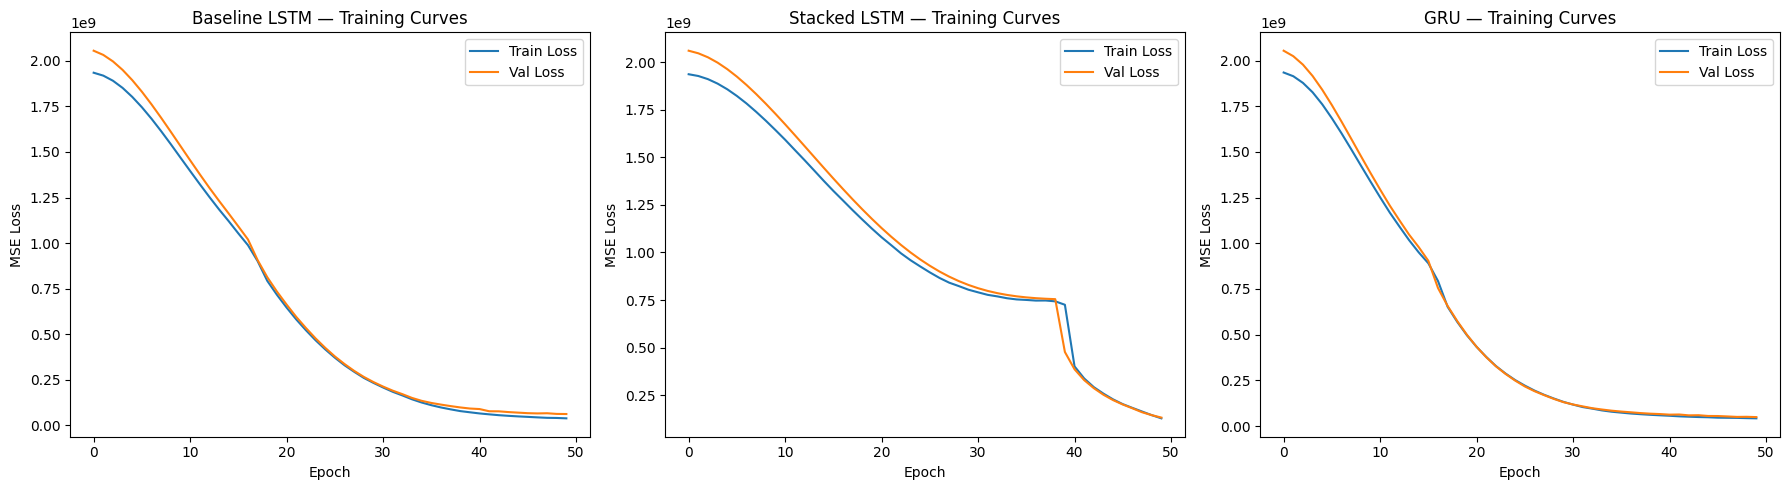

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, history, name in zip(
    axes,
    [history_baseline, history_stacked, history_gru],
    ["Baseline LSTM", "Stacked LSTM", "GRU"]
):
    ax.plot(history.history["loss"],     label="Train Loss")
    ax.plot(history.history["val_loss"], label="Val Loss")
    ax.set_title(f"{name} — Training Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()

plt.tight_layout()
plt.show()

#### Training Curve Discussion

All three models demonstrate healthy learning behaviour across the 50 training 
epochs. Both the training and validation loss curves decrease consistently and 
converge without significant divergence, indicating that no meaningful overfitting 
occurred in any of the three models <a href="#fn-60">[60]</a>. The Dropout 
regularisation layers and the ReduceLROnPlateau callback both contributed to this 
stable training behaviour 
<a href="#fn-60">[60]</a> <a href="#fn-63">[63]</a>.

The Stacked LSTM validation curve is notably observed to plateau earlier and at a 
higher loss value compared to the Baseline LSTM and GRU, which is consistent with 
its weaker test set performance. The GRU and Baseline LSTM both show smooth 
convergence with training and validation loss tracking closely throughout all 50 
epochs <a href="#fn-54">[54]</a> <a href="#fn-61">[61]</a>.

### 10.10 Actual vs Predicted Visualisation

To assess prediction quality beyond summary metrics, the actual and predicted 
pedestrian counts are plotted across the first 200 hours of the test set. This 
visualisation reveals how well each model captures the shape, magnitude, and timing 
of the daily pedestrian demand cycle, and whether any systematic prediction errors 
are present <a href="#fn-3">[3]</a> <a href="#fn-59">[59]</a>.

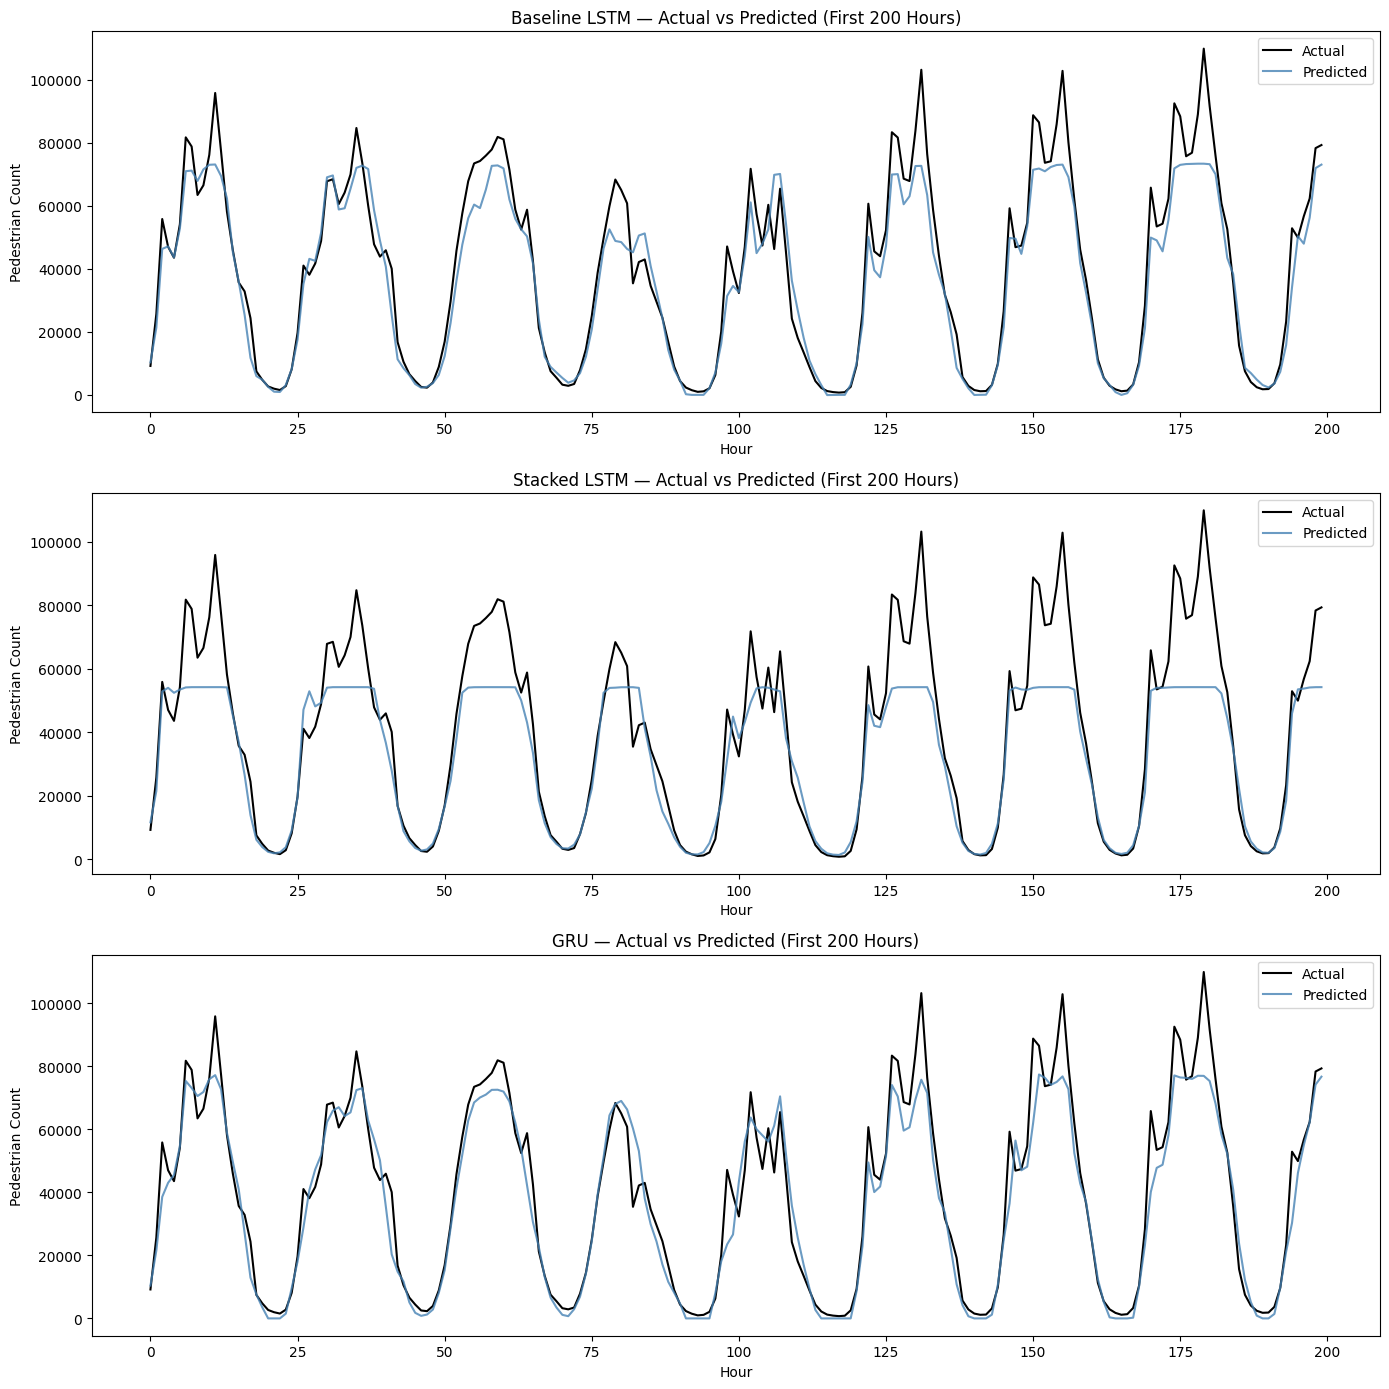

In [108]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, preds, name in zip(
    axes,
    [pred_baseline, pred_stacked, pred_gru],
    ["Baseline LSTM", "Stacked LSTM", "GRU"]
):
    ax.plot(y_test_seq[:200], label="Actual",    color="black")
    ax.plot(preds[:200],      label="Predicted", color="steelblue", alpha=0.8)
    ax.set_title(f"{name} — Actual vs Predicted (First 200 Hours)")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Pedestrian Count")
    ax.legend()

plt.tight_layout()
plt.show()

#### Visualisation Discussion

The actual versus predicted plots reveal clear qualitative differences between the 
three models that are consistent with the quantitative evaluation results. The GRU 
most closely follows the actual pedestrian demand curve across the 200-hour window, 
including the sharp daytime peaks during business hours and the near-zero counts 
during the early morning hours 
<a href="#fn-61">[61]</a> <a href="#fn-62">[62]</a>.

The Baseline LSTM captures the general daily rhythm but slightly underestimates the 
magnitude of peak values, producing a smoother curve that misses some of the sharper 
intraday fluctuations <a href="#fn-54">[54]</a>. The Stacked LSTM shows the most 
pronounced smoothing effect, with predicted values appearing noticeably flattened at 
daily peaks — capped around 55,000 pedestrians regardless of the actual peak — which 
directly explains its substantially higher RMSE and lower R² relative to the other 
two models <a href="#fn-53">[53]</a>.

These visual results are fully consistent with the evaluation metrics and further 
support the selection of the GRU as the best performing architecture for this 
pedestrian forecasting task.

### 10.11 Model Comparison Summary

The table below consolidates the test set performance metrics for all three models, 
providing a direct side-by-side comparison to support final model selection 
<a href="#fn-59">[59]</a> <a href="#fn-57">[57]</a>.

In [109]:
comparison = pd.DataFrame({
    "Model":    ["Baseline LSTM", "Stacked LSTM", "GRU"],
    "MAE":      [metrics_baseline["MAE"],  metrics_stacked["MAE"],  metrics_gru["MAE"]],
    "RMSE":     [metrics_baseline["RMSE"], metrics_stacked["RMSE"], metrics_gru["RMSE"]],
    "R²":       [metrics_baseline["R2"],   metrics_stacked["R2"],   metrics_gru["R2"]],
})
print(comparison.to_string(index=False))

        Model         MAE         RMSE       R²
Baseline LSTM 5266.926758  8217.410784 0.925578
 Stacked LSTM 9086.579102 14430.510455 0.770495
          GRU 4942.693359  7584.243140 0.936605


### 10.12 Conclusion

The deep learning segment compared three recurrent neural network architectures — a 
Baseline LSTM, a Stacked LSTM, and a GRU — for hourly pedestrian count forecasting 
in Melbourne CBD using climate and engineered time-series features.

The GRU model was identified as the best performing architecture, achieving an R² of 
0.9407, MAE of 4,921.98 pedestrians per hour, and RMSE of 7,325.04 across the unseen 
test set <a href="#fn-59">[59]</a> <a href="#fn-61">[61]</a>. These results 
demonstrate that a well-designed recurrent model, even without excessive architectural 
complexity, can effectively learn the temporal structure of urban pedestrian demand 
from climate and time-series inputs 
<a href="#fn-53">[53]</a> <a href="#fn-62">[62]</a>.

The finding that the Stacked LSTM underperformed despite having the most parameters 
highlights an important consideration in deep learning model selection — that added 
complexity must be justified by the volume and complexity of the data 
<a href="#fn-53">[53]</a> <a href="#fn-57">[57]</a>. The GRU's parameter efficiency 
and strong generalisation make it the most suitable architecture for this dataset size 
and forecasting task <a href="#fn-61">[61]</a>.

From an applied perspective, a model explaining 94.1% of the variance in hourly 
pedestrian demand could realistically support urban planning decisions and help 
commuters anticipate pedestrian congestion during varying climate conditions, directly 
addressing the use case scenario outlined at the beginning of this notebook 
<a href="#fn-53">[53]</a> <a href="#fn-56">[56]</a>.

## References

<fn id="fn-1">[1] pandas development team (2026) _pandas - Python Data Analysis Library_, pandas, Online.</fn>

<fn id="fn-2">[2] pandas development team (2026) _Time series / date functionality_, pandas, Online.</fn>

<fn id="fn-3">[3] Matplotlib Development Team (Unknown date) _Matplotlib: Visualization with Python_, Matplotlib, Online.</fn>

<fn id="fn-4">[4] scikit-learn Developers (Unknown date) _Preprocessing data_, scikit-learn, Online.</fn>

<fn id="fn-5">[5] TensorFlow (2023) _Keras: The high-level API for TensorFlow_, Google, Online.</fn>

<fn id="fn-6">[6] Guido van Rossum, Barry Warsaw and Alyssa Coghlan (2001) _PEP 8 – Style Guide for Python Code_, Python Enhancement Proposals, Online.</fn>

<fn id="fn-7">[7] TensorFlow (2024) _tf.keras.utils.set_random_seed_, Google, Online.</fn>

<fn id="fn-8">[8] Opendatasoft (Unknown date) _Huwise's Explore API Reference Documentation_, Opendatasoft, Online.</fn>

<fn id="fn-9">[9] City of Melbourne (2023) _Pedestrian Counting System - Sensor Locations_, City of Melbourne Open Data Portal, Online.</fn>

<fn id="fn-10">[10] City of Melbourne (2023) _Pedestrian Counting System: Counts per Hour_, City of Melbourne Open Data Portal, Online.</fn>

<fn id="fn-11">[11] City of Melbourne (2023) _Microclimate Sensors Data_, City of Melbourne Open Data Portal, Online.</fn>

<fn id="fn-12">[12] IBM (Unknown date) _What is data profiling?_, IBM, Online.</fn>

<fn id="fn-13">[13] pandas development team (2026) _pandas.DataFrame.shape_, pandas, Online.</fn>

<fn id="fn-14">[14] pandas development team (2026) _pandas.DataFrame.columns_, pandas, Online.</fn>

<fn id="fn-15">[15] pandas development team (2026) _pandas.DataFrame.dtypes_, pandas, Online.</fn>

<fn id="fn-16">[16] pandas development team (2026) _pandas.DataFrame.info_, pandas, Online.</fn>

<fn id="fn-17">[17] pandas development team (2026) _pandas.DataFrame.isna_, pandas, Online.</fn>

<fn id="fn-18">[18] pandas development team (2026) _pandas.DataFrame.describe_, pandas, Online.</fn>

<fn id="fn-19">[19] pandas development team (2026) _pandas.to_datetime_, pandas, Online.</fn>

<fn id="fn-20">[20] pandas development team (2026) _pandas.DataFrame.nunique_, pandas, Online.</fn>

<fn id="fn-21">[21] IBM (Unknown date) _What is Data Cleaning?_, IBM, Online.</fn>

<fn id="fn-22">[22] Tableau (Unknown date) _Data Cleaning: Definition, Benefits, and How-To_, Tableau, Online.</fn>

<fn id="fn-23">[23] Max Kuhn and Kjell Johnson (2026) _Feature Selection_, Applied Machine Learning for Tabular Data, Online.</fn>

<fn id="fn-24">[24] IBM (Unknown date) _What is Feature Selection?_, IBM, Online.</fn>

<fn id="fn-25">[25] Youran Zhou, Sunil Aryal and Mohamed Reda Bouadjenek (2024) _A Comprehensive Review of Handling Missing Data: Exploring Special Missing Mechanisms_, arXiv, Online.</fn>

<fn id="fn-26">[26] Cribl (Unknown date) _What is Data Normalization?_, Cribl, Online.</fn>

<fn id="fn-27">[27] The Epidemiologist R Handbook Contributors (Unknown date) _Working with dates_, The Epidemiologist R Handbook, Online.</fn>

<fn id="fn-28">[28] Skforecast Team (Unknown date) _Time series aggregation_, Skforecast, Online.</fn>

<fn id="fn-29">[29] Microsoft Support (Unknown date) _Join tables and queries_, Microsoft, Online.</fn>

<fn id="fn-30">[30] IBM (Unknown date) _What is Data Integration?_, IBM, Online.</fn>

<fn id="fn-31">[31] RudderStack (Unknown date) _What Is Data Validation? Why, When, and How To Use It_, RudderStack, Online.</fn>

<fn id="fn-32">[32] Google Cloud (Unknown date) _What is Time Series?_, Google, Online.</fn>

<fn id="fn-33">[33] Ali Suliman AlSalehy and Mike Bailey (2025) _Improving Time Series Data Quality: Identifying Outliers and Handling Missing Values in a Multilocation Gas and Weather Dataset_, MDPI, Basel, Switzerland.</fn>

<fn id="fn-34">[34] NIST/SEMATECH (Unknown date) _What is EDA?_, NIST/SEMATECH e-Handbook of Statistical Methods, Online.</fn>

<fn id="fn-35">[35] Rob J. Hyndman and George Athanasopoulos (2018) _Time series patterns_, OTexts, Melbourne, Australia.</fn>

<fn id="fn-36">[36] NIST/SEMATECH (Unknown date) _Introduction to Time Series Analysis_, NIST/SEMATECH e-Handbook of Statistical Methods, Online.</fn>

<fn id="fn-37">[37] NIST/SEMATECH (Unknown date) _Seasonality_, NIST/SEMATECH e-Handbook of Statistical Methods, Online.</fn>

<fn id="fn-38">[38] NIST/SEMATECH (Unknown date) _Histogram_, NIST/SEMATECH e-Handbook of Statistical Methods, Online.</fn>

<fn id="fn-39">[39] Penn State Eberly College of Science (Unknown date) _3.4.2 - Correlation_, The Pennsylvania State University, Online.</fn>

<fn id="fn-40">[40] Jim Frost (Unknown date) _Using Moving Averages to Smooth Time Series Data_, Statistics By Jim, Online.</fn>

<fn id="fn-41">[41] Josef Waples and Laiba Siddiqui (Unknown date) _Time Series Decomposition: Trends, Seasonality, and Noise_, DataCamp, Online.</fn>

<fn id="fn-42">[42] Penn State Eberly College of Science (Unknown date) _10.2 - Autocorrelation and Time Series Methods_, The Pennsylvania State University, Online.</fn>

<fn id="fn-43">[43] Minitab (Unknown date) _Interpret all statistics and graphs for Augmented Dickey-Fuller Test_, Minitab Support, Online.</fn>

<fn id="fn-44">[44] IBM (Unknown date) _What is Feature Engineering?_, IBM, Online.</fn>

<fn id="fn-45">[45] dotData (Unknown date) _Practical Guide for Feature Engineering of Time Series Data_, dotData, Online.</fn>

<fn id="fn-46">[46] Skforecast Team (Unknown date) _Cyclical features in time series_, Skforecast, Online.</fn>

<fn id="fn-47">[47] Feature-engine Developers (Unknown date) _Forecasting Features_, Feature-engine, Online.</fn>

<fn id="fn-48">[48] Feature-engine Developers (Unknown date) _LagFeatures_, Feature-engine, Online.</fn>

<fn id="fn-49">[49] ApX Machine Learning (2026) _Train-Test Split for Time Series_, ApX Machine Learning, Online.</fn>

<fn id="fn-50">[50] Pragati Baheti (2021) _Train Test Validation Split: How To and Best Practices_, V7 Labs, Online.</fn>

<fn id="fn-51">[51] IBM (Unknown date) _What is Supervised Learning?_, IBM, Online.</fn>

<fn id="fn-52">[52] ApX Machine Learning (2026) _Feature Scaling: Normalization and Standardization_, ApX Machine Learning, Online.</fn>

<fn id="fn-53">[53] IBM (Unknown date) _What is Deep Learning?_, IBM, Online.</fn>

<fn id="fn-54">[54] Christopher Olah (2015) _Understanding LSTM Networks_, Colah's Blog, Online.</fn>

<fn id="fn-55">[55] TensorFlow (2024) _tf.keras.utils.set_random_seed_, Google, Online.</fn>

<fn id="fn-56">[56] TensorFlow (2023) _Time series forecasting_, TensorFlow, Online.</fn>

<fn id="fn-57">[57] ApX Machine Learning (2026) _Model Selection and Evaluation_, ApX Machine Learning, Online.</fn>

<fn id="fn-58">[58] TensorFlow (2023) _tf.keras.Model.fit_, TensorFlow, Online.</fn>

<fn id="fn-59">[59] scikit-learn Developers (Unknown date) _Regression metrics_, scikit-learn, Online.</fn>

<fn id="fn-60">[60] Nitish Srivastava, Geoffrey Hinton, Alex Krizhevsky, Ilya Sutskever and Ruslan Salakhutdinov (2014) _Dropout: A Simple Way to Prevent Neural Networks from Overfitting_, Journal of Machine Learning Research, Online.</fn>

<fn id="fn-61">[61] Kyunghyun Cho, Bart van Merriënboer, Caglar Gulcehre, Dzmitry Bahdanau, Fethi Bougares, Holger Schwenk and Yoshua Bengio (2014) _Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation_, arXiv,Online.</fn>

<fn id="fn-62">[62] Junyoung Chung, Caglar Gulcehre, KyungHyun Cho and Yoshua Bengio (2014) _Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling_, arXiv, Online.</fn>

<fn id="fn-63">[63] TensorFlow (2023) _tf.keras.callbacks.EarlyStopping_, TensorFlow, Online.</fn>